In [122]:
# Global Setup & Data Preparation (Unified GitHub Source)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import geopandas as gpd
import requests
import warnings
from scipy import stats
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
from matplotlib.colors import to_rgba # Added
import matplotlib.patches as mpatches # Added
try:
    from adjustText import adjust_text
except:
    import subprocess
    try:
        subprocess.check_call(["pip", "install", "adjustText"])
        from adjustText import adjust_text
    except:
        print("Warning: adjustText could not be installed.")

warnings.filterwarnings("ignore")

# --- Font Setup ---
plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False

# --- GitHub Data Paths ---
GITHUB_BASE = "https://raw.githubusercontent.com/Gorszet/DADS5001_Election_2569/refs/heads/main/"

def load_github_json(filename):
    url = GITHUB_BASE + filename
    response = requests.get(url)
    response.encoding = "utf-8"
    return response.json()

# --- 1. Load and Flatten JSONs ---
print("Loading data from GitHub...")

# Province
df_province = pd.json_normalize(load_github_json("info_province.json")["province"])
df_province["prov_id"] = df_province["prov_id"].astype(str).str.strip()

# Constituency
df_constituencies = pd.json_normalize(load_github_json("info_constituency.json"))
if "zone" in df_constituencies.columns:
    df_constituencies["zone"] = df_constituencies["zone"].apply(lambda x: ", ".join(x) if isinstance(x, list) else x)
df_constituencies["prov_id"] = df_constituencies["prov_id"].astype(str).str.strip()
df_constituencies["cons_id"] = df_constituencies["cons_id"].astype(str).str.strip()

# MP Candidates
df_mp_candidates = pd.json_normalize(load_github_json("info_mp_candidate.json"))

# Party Overview
df_party_overview = pd.json_normalize(load_github_json("info_party_overview.json"))
df_party_overview["id"] = pd.to_numeric(df_party_overview["id"], errors="coerce")
party_colors = df_party_overview.set_index('name')['color'].to_dict() # Added

# Party Candidates
data_party_cand = load_github_json("info_party_candidate.json")
list_cands, pm_cands = [], []
for party in data_party_cand:
    p_no = party.get("party_no")
    for lc in party.get("party_list_candidates", []):
        lc["party_no"] = p_no
        list_cands.append(lc)
    for pc in party.get("pm_candidates", []):
        pc["party_no"] = p_no
        pm_cands.append(pc)
df_party_list_candidates = pd.DataFrame(list_cands)
df_pm_candidates = pd.DataFrame(pm_cands)
df_party_candidate = df_party_list_candidates # Alias

# Stats Party
data_stats_party = load_github_json("stats_party.json")
p_sums, p_winners = [], []
for p in data_stats_party.get("result_party", []):
    p_sums.append({k: v for k, v in p.items() if k != "candidates"})
    for c in p.get("candidates", []):
        c["party_id"] = p.get("id")
        p_winners.append(c)
df_stats_party_results = pd.DataFrame(p_sums)
df_stats_party_winning_mp = pd.DataFrame(p_winners)

# Stats Cons
data_stats_cons = load_github_json("stats_cons.json")
c_sums, c_cands, c_party_votes = [], [], []
for prov in data_stats_cons.get("result_province", []):
    for cons in prov.get("constituencies", []):
        c_sums.append({k: v for k, v in cons.items() if k not in ("candidates", "result_party")})
        for cand in cons.get("candidates", []):
            cand["cons_id"] = cons["cons_id"]
            c_cands.append(cand)
        for p in cons.get("result_party", []):
            p["cons_id"] = cons["cons_id"]
            c_party_votes.append(p)
df_stats_cons_summary = pd.DataFrame(c_sums)
df_stats_cons_cand = pd.DataFrame(c_cands)
df_stats_cons_party = pd.DataFrame(c_party_votes)
df_stats_cons_summary["cons_id"] = df_stats_cons_summary["cons_id"].astype(str).str.strip()
df_stats_cons_cand["cons_id"] = df_stats_cons_cand["cons_id"].astype(str).str.strip()
df_stats_cons_party["cons_id"] = df_stats_cons_party["cons_id"].astype(str).str.strip()

# --- 2. Baan Yhai Data ---
print("Loading Baan Yhai data...")
try:
    xlsx_url = GITHUB_BASE + "ตระกูลบ้านใหญ่.xlsx"
    df_baan_yhai = pd.read_excel(xlsx_url)
except:
    df_baan_yhai = None

# --- 3. Region Mapping ---
regions_map = {
    "Northern": ["เชียงราย", "เชียงใหม่", "น่าน", "พะเยา", "แพร่", "แม่ฮ่องสอน", "ลำปาง", "ลำพูน", "อุตรดิตถ์", "สุโขทัย", "พิษณุโลก", "กำแพงเพชร"],
    "Northeastern": ["กาฬสินธุ์", "ขอนแก่น", "ชัยภูมิ", "นครพนม", "นครราชสีมา", "บึงกาฬ", "บุรีรัมย์", "มหาสารคาม", "มุกดาหาร", "ยโสธร", "ร้อยเอ็ด", "เลย", "สกลนคร", "สุรินทร์", "ศรีสะเกษ", "หนองคาย", "หนองบัวลำภู", "อุดรธานี", "อุบลราชธานี", "อำนาจเจริญ"],
    "Central": ["นครสวรรค์", "พิจิตร", "เพชรบูรณ์", "อุทัยธานี", "ชัยนาท", "สิงห์บุรี", "อ่างทอง", "ลพบุรี", "สระบุรี", "พระนครศรีอยุธยา", "ปทุมธานี", "นนทบุรี", "นครปฐม", "สมุทรสาคร", "สมุทรสงคราม", "สมุทรปราการ", "นครนายก", "สุพรรณบุรี"],
    "Eastern": ["จันทบุรี", "ฉะเชิงเทรา", "ชลบุรี", "ตราด", "ปราจีนบุรี", "ระยอง", "สระแก้ว"],
    "Western": ["ตาก", "กาญจนบุรี", "ราชบุรี", "เพชรบุรี", "ประจวบคีรีขันธ์"],
    "Southern": ["กระบี่", "ชุมพร", "ตรัง", "นครศรีธรรมราช", "นราธิวาส", "ปัตตานี", "พังงา", "พัทลุง", "ภูเก็ต", "ระนอง", "สตูล", "สงขลา", "สุราษฎร์ธานี", "ยะลา"],
    "Bangkok": ["กรุงเทพมหานคร"]
}
p_to_r = {p: r for r, ps in regions_map.items() for p in ps}
df_province["region"] = df_province["province"].map(p_to_r)

# --- 4. Core Merges ---
df_cand_full = df_stats_cons_cand.merge(
    df_mp_candidates[["mp_app_id", "mp_app_name", "mp_app_party_id"]], on="mp_app_id", how="left"
).merge(
    df_party_overview[["id", "name", "color"]].rename(columns={"id": "mp_app_party_id", "name": "party_name"}), on="mp_app_party_id", how="left"
)

if df_baan_yhai is not None:
    df_cand_full = df_cand_full.merge(df_baan_yhai, on="mp_app_name", how="left")
    df_cand_full["is_baan_yhai"] = df_cand_full["baan_yhai_group"].notna()

df_cons_geo = df_stats_cons_summary.merge(
    df_constituencies[["cons_id", "prov_id", "cons_no"]], on="cons_id", how="left"
).merge(
    df_province[["prov_id", "province", "region"]], on="prov_id", how="left"
)

df_party_full = df_stats_cons_party.merge(
    df_party_overview[["id", "name", "color"]].rename(columns={"id": "party_id", "name": "party_name"}), on="party_id", how="left"
)

# --- 5. Global Aliases for All Sections ---
df_constituency = df_constituencies
df_mp = df_mp_candidates
df_mp_candidate = df_mp_candidates
df_party = df_party_overview
df_party_info = df_party_overview
df_party_overview_alias = df_party_overview
df_regions = df_province[["prov_id", "province", "region"]]
df_valid_cons = df_cons_geo
df_stats_cons = df_stats_cons_summary
df_stats_party = df_stats_party_results
df_prov_full = df_province
regions = regions_map

print("Master Dataframes ready for all sections.")

Loading data from GitHub...
Loading Baan Yhai data...
Master Dataframes ready for all sections.


In [123]:
# Create split_ticket_df by merging candidate votes with party-list votes and party info
split_ticket_df = df_stats_cons_cand.merge(
    df_stats_cons_party[['cons_id', 'party_id', 'party_list_vote', 'party_list_vote_percent']],
    on=['cons_id', 'party_id'],
    how='left'
).merge(
    df_party_overview[['id', 'name', 'color']].rename(columns={'id': 'party_id', 'name': 'party_name'}),
    on='party_id',
    how='left'
)

# Create winner_split_df by filtering for winning candidates
winner_split_df = split_ticket_df[split_ticket_df['mp_app_rank'] == 1].copy()

# Define color constants for consistent plotting
REFERENCE_LINE = '#8e44ad'
BEHAVIOR_COLORS = ['#2B4660', '#5B7E99', '#B0C8D4']  # Colors for Personality, Brand, Loyalist
NONPARTY_SINGLE = '#1abc9c'
HEATMAP_CMAP = 'YlGnBu'  # Colormap for heatmaps

In [124]:
# Join 1: Candidate names + party IDs
df_cand_full = df_stats_cons_cand.merge(
    df_mp_candidates[['mp_app_id','mp_app_name','mp_app_party_id']],
    on='mp_app_id', how='left'
)

# Join 2: Party names + colors
df_cand_full = df_cand_full.merge(
    df_party_overview[['id','name','color']].rename(columns={'id':'mp_app_party_id','name':'party_name'}),
    on='mp_app_party_id', how='left'
)

# Join 3: Province + region onto constituency summaries
df_cons_geo = df_stats_cons_summary.merge(
    df_constituencies[['cons_id','prov_id','cons_no']], on='cons_id', how='left'
).merge(
    df_regions[['prov_id','province','region']], on='prov_id', how='left'
)

# Party vote dataframe
df_party_full = df_stats_cons_party.merge(
    df_party_overview[['id','name','color']].rename(columns={'id':'party_id','name':'party_name'}),
    on='party_id', how='left'
)

df_valid_cons = df_cons_geo[df_cons_geo['percent_turn_out'] > 0].copy()
df_valid_cons['eligible_voters'] = (
    df_valid_cons['turn_out'] / (df_valid_cons['percent_turn_out'] / 100)
).fillna(0).round().astype(int)

party_colors = dict(zip(df_party_overview['name'], df_party_overview['color']))

print('party_colors sample:', dict(list(party_colors.items())[:4]))
print('df_valid_cons shape:', df_valid_cons.shape)
display(df_cand_full.head(3))

party_colors sample: {'ไทยทรัพย์ทวี': '#f02d30', 'เพื่อชาติไทย': '#724a34', 'ใหม่': '#da3731', 'มิติใหม่': '#abc29d'}
df_valid_cons shape: (400, 19)


,mp_app_id,mp_app_vote,mp_app_vote_percent,mp_app_rank,party_id,cons_id,mp_app_name,mp_app_party_id,party_name,color
0,BKK_1_5,32564,44.39294,1,129.0,BKK_1,นายปารเมศ วิทยารักษ์สรรค์,129.0,ประชาชน,#fd6512
1,BKK_1_9,14018,19.11007,2,1.0,BKK_1,นายพีรวุฒิ พิมพ์สมฤดี,1.0,ประชาธิปัตย์,#06aff3
2,BKK_1_1,13661,18.62339,3,63.0,BKK_1,นางสาวลลิดา เพริศวิวัฒนา,63.0,ภูมิใจไทย,#0c149c


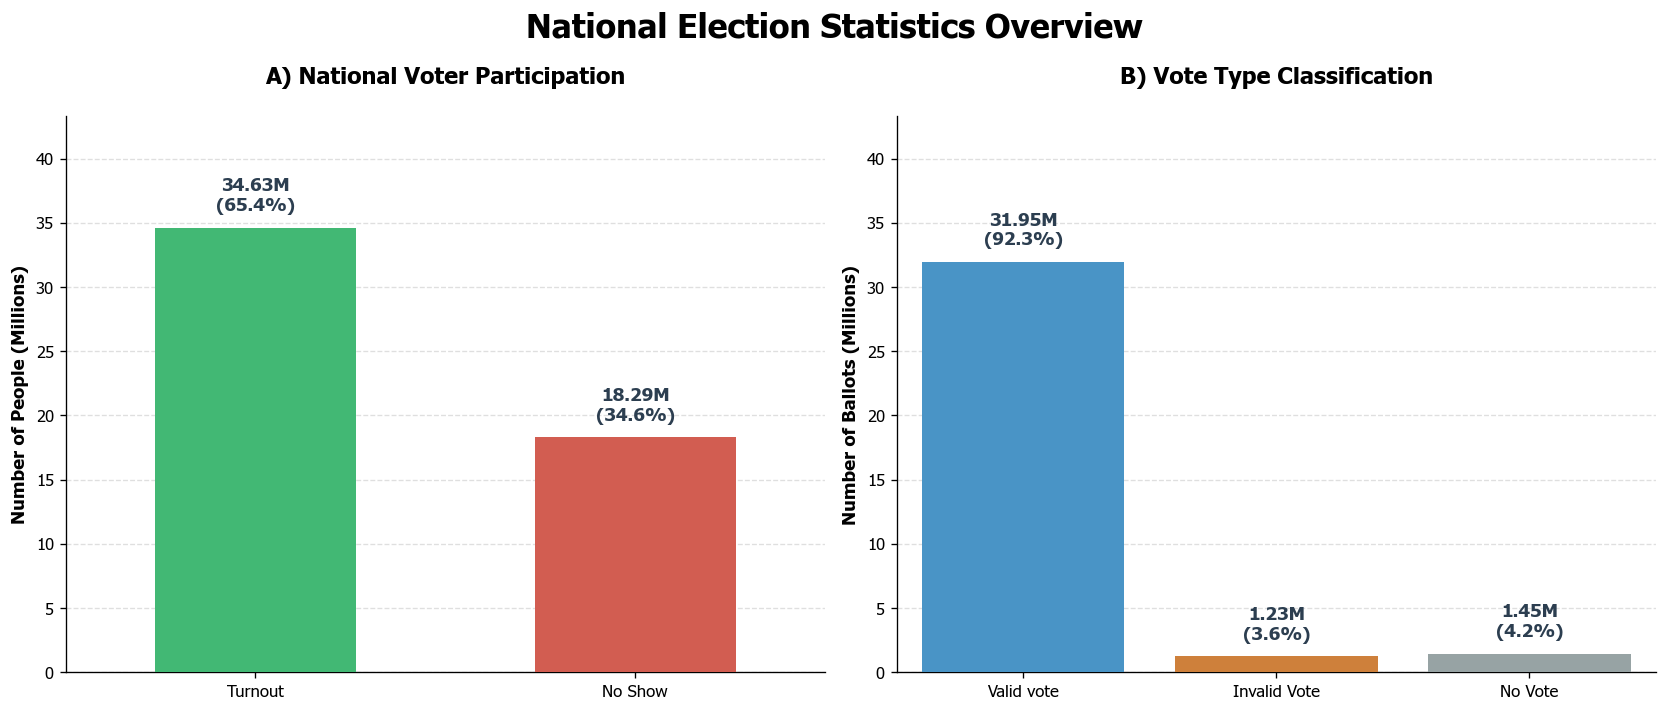

In [125]:
# National Statistic Overview
import matplotlib.pyplot as plt
import seaborn as sns

col_eligible = 'eligible_voters' if 'eligible_voters' in df_valid_cons.columns else 'eligible'
total_eligible = df_valid_cons[col_eligible].sum()
total_turnout = df_valid_cons['turn_out'].sum()
total_no_show = total_eligible - total_turnout

total_valid = df_valid_cons['valid_votes'].sum()
total_invalid = df_valid_cons['invalid_votes'].sum()
total_no_vote = df_valid_cons['blank_votes'].sum()

# Figure 1: National Voter Turnout
# แบ่งเป็น 2 Charts แยกกัน แต่สเกล Y เท่ากัน
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Tahoma'
BG_COLOR = '#ffffff'

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=BG_COLOR)
plt.subplots_adjust(wspace=0.3)

cat_left = ['Turnout', 'No Show']
val_left = [total_turnout / 1e6, total_no_show / 1e6]
color_left = ['#2ecc71', '#e74c3c']

cat_right = ['Valid vote', 'Invalid Vote', 'No Vote']
val_right = [total_valid / 1e6, total_invalid / 1e6, total_no_vote / 1e6]
color_right = ['#3498db', '#e67e22', '#95a5a6']

# หาค่าที่สูงที่สุดจากทั้งสองฝั่ง เพื่อกำหนดเพดานแกน Y ให้เท่ากัน
global_max = max(max(val_left), max(val_right))
unified_ylim = global_max * 1.25

# Chart A
sns.barplot(x=cat_left, y=val_left, palette=color_left,
            linewidth=1, ax=axes[0], width=0.53, zorder=3)

for i, v in enumerate(val_left):
    pct = (v * 1e6 / total_eligible) * 100
    axes[0].text(i, v + (global_max * 0.03), f"{v:.2f}M\n({pct:.1f}%)", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2c3e50', zorder=4)

axes[0].set_title('A) National Voter Participation', fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Number of People (Millions)', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, unified_ylim) # ล็อคแกน Y ด้วยค่า unified_ylim
axes[0].set_facecolor(BG_COLOR)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4, zorder=1)
axes[0].set_axisbelow(True)

# Chart B
sns.barplot(x=cat_right, y=val_right, palette=color_right,
            linewidth=1, ax=axes[1], width=0.8, zorder=3)

for i, v in enumerate(val_right):
    pct = (v * 1e6 / total_turnout) * 100
    axes[1].text(i, v + (global_max * 0.03), f"{v:.2f}M\n({pct:.1f}%)", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2c3e50', zorder=4)

axes[1].set_title('B) Vote Type Classification', fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('Number of Ballots (Millions)', fontsize=11, fontweight='bold') # ใส่ชื่อแกน Y คืนให้ฝั่งขวา
axes[1].set_ylim(0, unified_ylim) # ล็อคแกน Y ด้วยค่า unified_ylim ให้เท่ากับฝั่งซ้ายเป๊ะๆ
axes[1].set_facecolor(BG_COLOR)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.4, zorder=1)
axes[1].set_axisbelow(True)

plt.suptitle('National Election Statistics Overview', 
             fontsize=20, fontweight='bold')
for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
# plt.savefig('1.1 Election statistic 2026.png', dpi=300, bbox_inches='tight')
plt.show()

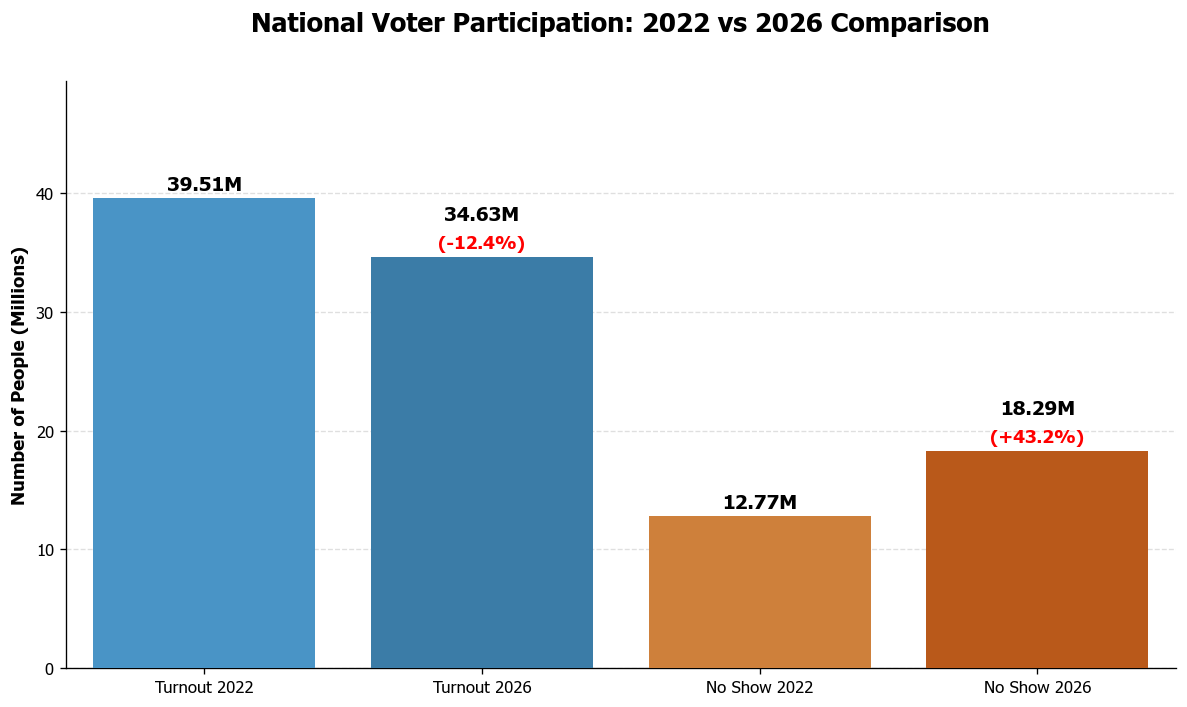

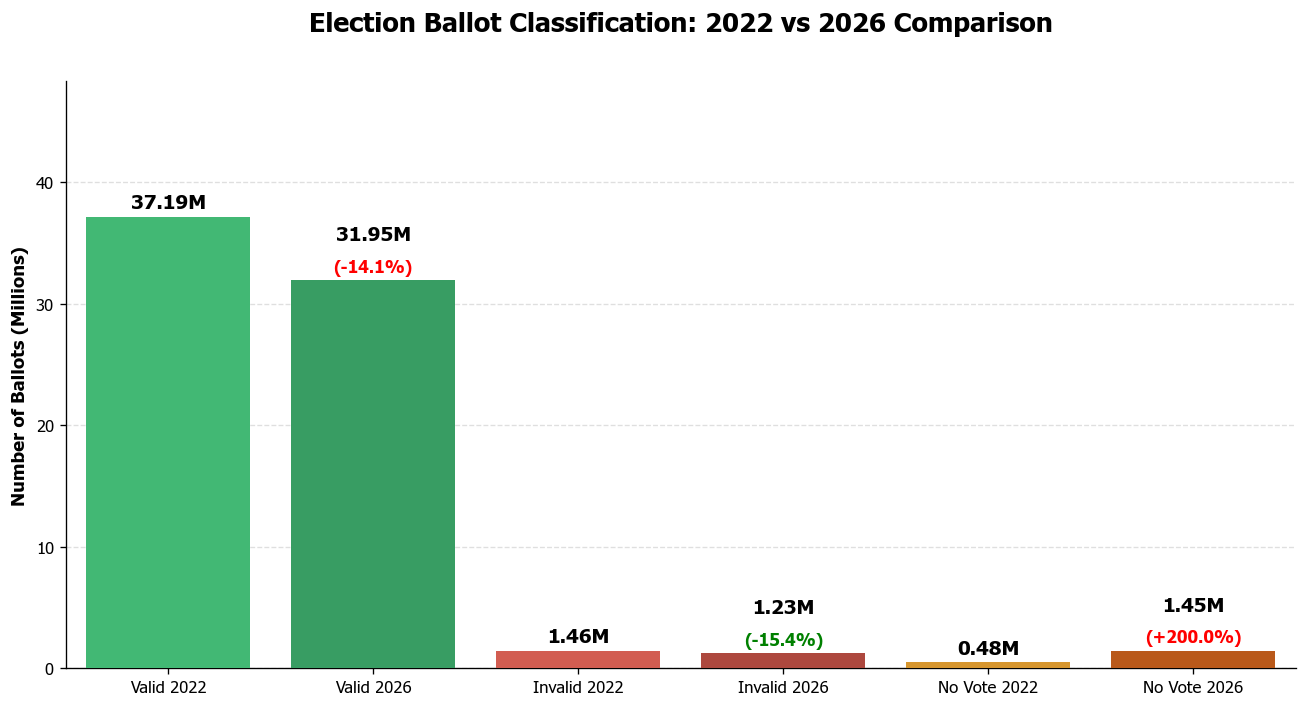

In [126]:
# Compare voter Y2022 vs Y2026

# Data Election Y2022
total_eligible_2022 = 52287045
total_turnout_2022 = 39514973
total_no_show_2022 = total_eligible_2022 - total_turnout_2022
valid_votes_2022 = 37190071
invalid_votes_2022 = 1457889
total_no_vote_2022 = 482258

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Tahoma'
BG_COLOR = '#ffffff'

# Figure 1: Voter Turnout Comparison (2022 vs 2026)
plt.figure(figsize=(10, 6), facecolor=BG_COLOR)
ax_compare = plt.gca()
ax_compare.set_facecolor(BG_COLOR)

cat_compare = ['Turnout 2022', 'Turnout 2026', 'No Show 2022', 'No Show 2026']
val_compare = [total_turnout_2022, total_turnout, total_no_show_2022, total_no_show]
val_compare_m = [v / 1_000_000 for v in val_compare]
color_compare = ['#3498db', '#2980b9', '#e67e22', '#d35400'] # ไล่โทนสีให้ดูโมเดิร์นขึ้น

sns.barplot(x=cat_compare, y=val_compare_m, palette=color_compare, linewidth=0.8, zorder = 3)

for i, v_m in enumerate(val_compare_m):
    offset_main = max(val_compare_m) * 0.07
    offset_pct = max(val_compare_m) * 0.01

    if i % 2 == 1:  # เฉพาะข้อมูลปี 2026 (เพื่อเทียบกับปี 2022)
        prev_v = val_compare[i-1]
        pct = ((val_compare[i] - prev_v) / prev_v) * 100
        
        # No Show เพิ่ม = แดง | Turnout ลด = แดง
        is_no_show = 'No Show' in cat_compare[i]
        color_pct = 'red' if (pct > 0 if is_no_show else pct < 0) else 'green'

        ax_compare.text(i, v_m + offset_main, f"{v_m:,.2f}M", 
                        ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
        ax_compare.text(i, v_m + offset_pct, f"({pct:+.1f}%)", 
                        ha='center', va='bottom', fontsize=11, fontweight='bold', color=color_pct)
    else:
        ax_compare.text(i, v_m + offset_pct, f"{v_m:,.2f}M", 
                        ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.title('National Voter Participation: 2022 vs 2026 Comparison', 
          fontsize=16, fontweight='bold', pad=30, x=0.5, loc='center')
plt.ylabel('Number of People (Millions)', fontsize=11, fontweight='bold')
plt.ylim(0, max(val_compare_m) * 1.25)
ax_compare.yaxis.grid(True, linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.axis()
# plt.savefig('1.2 participation 2022 vs 2026.png', dpi=120)
plt.show()

# 2. Vote Type Comparison (2022 vs 2026)
plt.figure(figsize=(11, 6), facecolor=BG_COLOR)
ax_vote_type = plt.gca()
ax_vote_type.set_facecolor(BG_COLOR)

cat_vote_type = ['Valid 2022', 'Valid 2026', 'Invalid 2022', 'Invalid 2026', 'No Vote 2022', 'No Vote 2026']
val_vote_type = [valid_votes_2022, total_valid, invalid_votes_2022, total_invalid, total_no_vote_2022, total_no_vote]
val_vote_type_m = [v / 1_000_000 for v in val_vote_type] # ปรับเป็นหน่วยล้านเหมือนกันเพื่อความ Consistent
color_vote_type = ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b', '#f39c12', '#d35400']

sns.barplot(x=cat_vote_type, y=val_vote_type_m, palette=color_vote_type, linewidth=0.8, zorder=3)
for i, v_m in enumerate(val_vote_type_m):
    offset_main = max(val_vote_type_m) * 0.08
    offset_pct = max(val_vote_type_m) * 0.01

    if i % 2 == 1:  # เฉพาะปี 2026
        prev_v_raw = val_vote_type[i-1]
        pct = ((val_vote_type[i] - prev_v_raw) / prev_v_raw) * 100
        
        # Invalid หรือ No Vote เพิ่ม (>0) = แดง | Valid ลด (<0) = แดง
        is_bad_type = ('Invalid' in cat_vote_type[i]) or ('No Vote' in cat_vote_type[i])
        color_pct = 'red' if (pct > 0 if is_bad_type else pct < 0) else 'green'

        ax_vote_type.text(i, v_m + offset_main, f"{v_m:,.2f}M", 
                          ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
        ax_vote_type.text(i, v_m + offset_pct, f"({pct:+.1f}%)", 
                          ha='center', va='bottom', fontsize=10, fontweight='bold', color=color_pct)
    else:
        ax_vote_type.text(i, v_m + offset_pct, f"{v_m:,.2f}M", 
                          ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

plt.title('Election Ballot Classification: 2022 vs 2026 Comparison', 
          fontsize=16, fontweight='bold', pad=30, x=0.5, loc='center')
plt.ylabel('Number of Ballots (Millions)', fontsize=11, fontweight='bold')
plt.ylim(0, max(val_vote_type_m) * 1.3)
ax_vote_type.yaxis.grid(True, linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
# plt.savefig('1.3 ballot classification 2022 vs 2026.png', dpi=120)
plt.show()

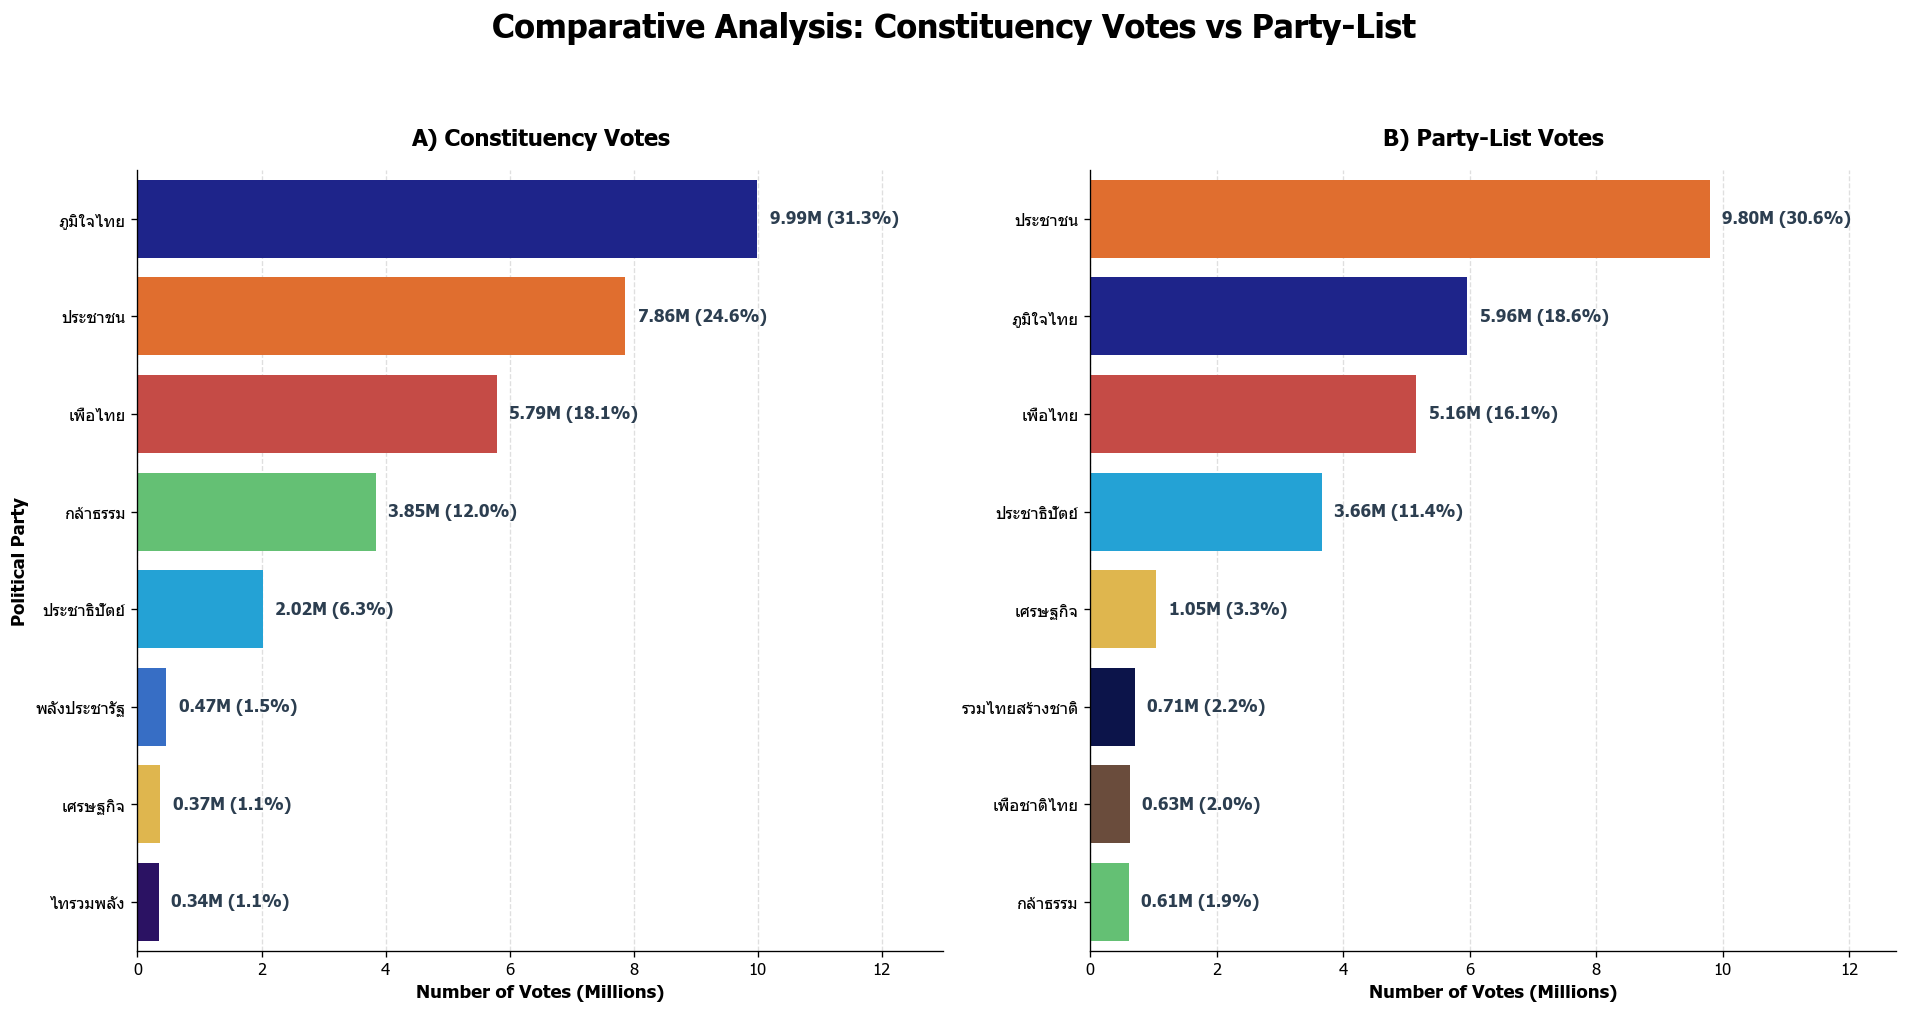

In [127]:
# Comparative Analysis: Constituency Votes vs Party-List เทียบระหว่าง

party_list_votes_all = df_party_full.groupby(['party_name','color','party_id'])['party_list_vote'].sum().reset_index()
cons_votes_all       = df_cand_full.groupby(['party_name','color','mp_app_party_id'])['mp_app_vote'].sum().reset_index()

party_list_votes_all['vote_millions'] = party_list_votes_all['party_list_vote'] / 1_000_000
cons_votes_all['vote_millions']       = cons_votes_all['mp_app_vote'] / 1_000_000

total_pl_nat   = party_list_votes_all['party_list_vote'].sum()
total_cons_nat = cons_votes_all['mp_app_vote'].sum()
party_list_votes_all['PL_Share']  = (party_list_votes_all['party_list_vote'] / total_pl_nat) * 100
cons_votes_all['Cons_Share']      = (cons_votes_all['mp_app_vote'] / total_cons_nat) * 100

# เลือก Top 8 พรรคที่มีคะแนนสูงสุด
party_list_viz = party_list_votes_all.sort_values('vote_millions', ascending=False).head(8)
cons_votes_viz = cons_votes_all.sort_values('vote_millions', ascending=False).head(8)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Tahoma'
BG_COLOR = '#ffffff'

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor=BG_COLOR)
plt.subplots_adjust(wspace=0.35)

# ผลคะแนนการเลือกตั้งสส.เขต
sns.barplot(data=cons_votes_viz, x='vote_millions', y='party_name',
            palette=cons_votes_viz['color'].tolist(), ax=axes[0], linewidth=0.8)

axes[0].set_title('A) Constituency Votes', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Votes (Millions)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Political Party', fontsize=11, fontweight='bold')

max_cons = cons_votes_viz['vote_millions'].max()
for i, v in enumerate(cons_votes_viz['vote_millions']):
    share = cons_votes_viz.iloc[i]['Cons_Share']
    axes[0].text(v + (max_cons * 0.02), i, f'{v:.2f}M ({share:.1f}%)', 
                 va='center', fontsize=10, fontweight='bold', color='#2c3e50')
axes[0].set_xlim(0, max_cons * 1.3)
axes[0].set_axisbelow(True)

# ผลคะแนนการเลือกตั้งสส.บัญชีรายชื่อ
sns.barplot(data=party_list_viz, x='vote_millions', y='party_name',
            palette=party_list_viz['color'].tolist(), ax=axes[1], linewidth=0.8)

axes[1].set_title('B) Party-List Votes', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Number of Votes (Millions)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('')

max_pl = party_list_viz['vote_millions'].max()
for i, v in enumerate(party_list_viz['vote_millions']):
    share = party_list_viz.iloc[i]['PL_Share']
    axes[1].text(v + (max_pl * 0.02), i, f'{v:.2f}M ({share:.1f}%)', 
                 va='center', fontsize=10, fontweight='bold', color='#2c3e50')
axes[1].set_xlim(0, max_pl * 1.3)
axes[1].set_axisbelow(True)

for ax in axes:
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    ax.set_facecolor(BG_COLOR)
    sns.despine(ax=ax)

plt.suptitle('Comparative Analysis: Constituency Votes vs Party-List', 
             fontsize=20, fontweight='bold', y=1.05, x=0.5)
plt.tight_layout()
# plt.savefig('1.4_constituency_vs_party_list.png', dpi=300, bbox_inches='tight')
plt.show()

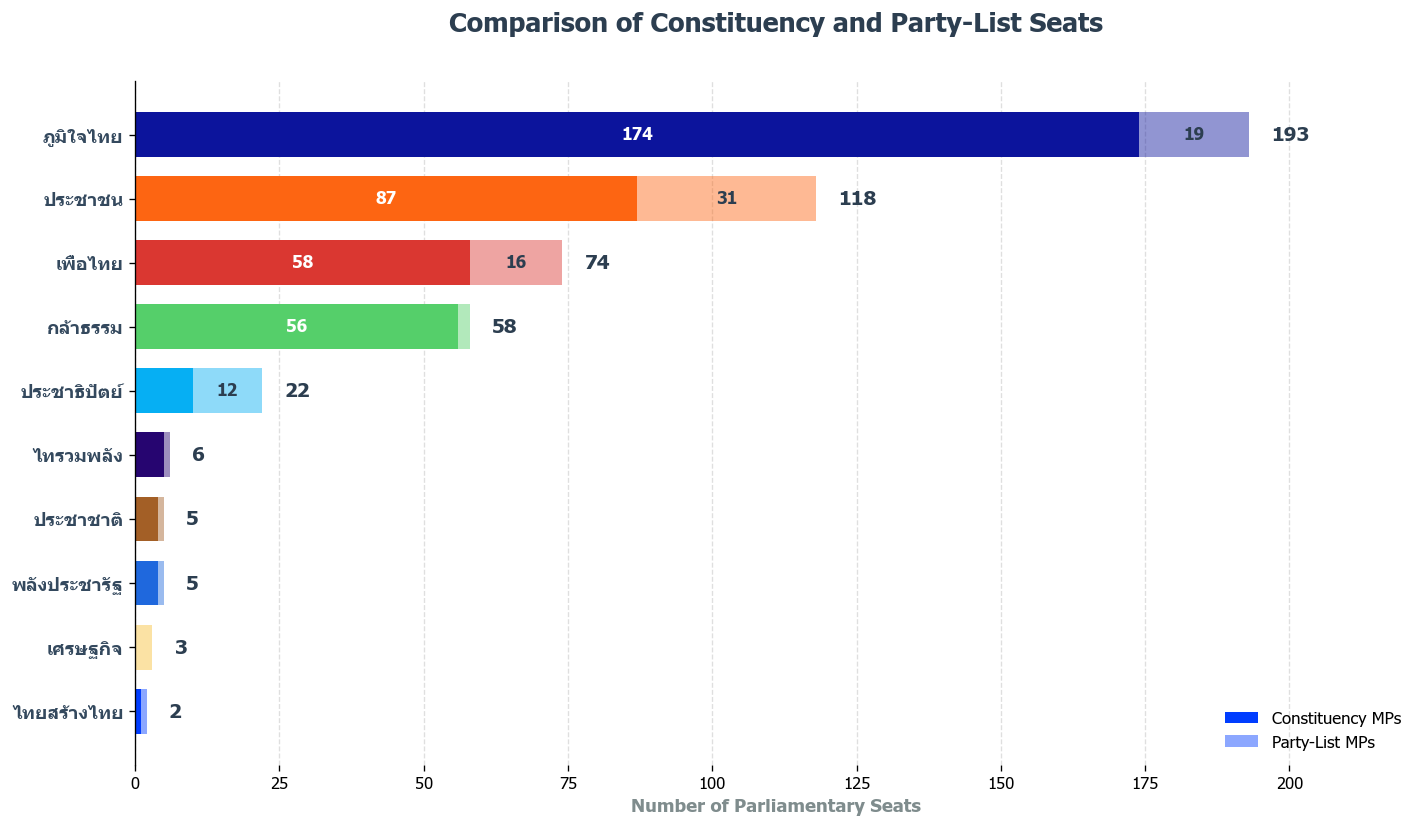

In [128]:
# Constituency and Party list seat

df_winners = df_cand_full[df_cand_full['mp_app_rank'] == 1].copy()

if 'party_name' not in df_winners.columns:
    df_winners = df_winners.merge(
        df_party_overview[['id', 'name']].rename(columns={'id': 'mp_app_party_id', 'name': 'party_name'}),
        on='mp_app_party_id',
        how='left'
    )

cons_seats = df_winners['party_name'].value_counts().reset_index()
cons_seats.columns = ['party_name', 'cons_seats']

pl_votes = df_party_full.groupby('party_name')['party_list_vote'].sum().reset_index()
total_pl_votes = pl_votes['party_list_vote'].sum()
quota = total_pl_votes / 100

pl_votes['pl_seats'] = np.floor(pl_votes['party_list_vote'] / quota).astype(int)
pl_votes['remainder'] = pl_votes['party_list_vote'] % quota
rem_seats = 100 - pl_votes['pl_seats'].sum()
if rem_seats > 0:
    top_remainders = pl_votes.nlargest(int(rem_seats), 'remainder').index
    pl_votes.loc[top_remainders, 'pl_seats'] += 1

pl_seats = pl_votes[['party_name', 'pl_seats']]

# เฉพาะ Top 10 พรรคที่ได้ที่นั่งสูงสุด
final_seats = pd.merge(cons_seats, pl_seats, on='party_name', how='outer').fillna(0)
final_seats['total_seats'] = final_seats['cons_seats'] + final_seats['pl_seats']
final_seats = final_seats.sort_values('total_seats', ascending=True).tail(10) # เรียงเพื่อให้ตัวท็อปอยู่บนสุดในกราฟแนวนอน

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Tahoma'
BG_COLOR = '#ffffff'

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)
ax.set_axisbelow(True)

y_pos = np.arange(len(final_seats))
# ดึงสีพรรค
base_colors = [party_colors.get(p, '#bdc3c7') for p in final_seats['party_name']]

# Constituency: สีทึบ | Party-List: สีจาง 50%
ax.barh(y_pos, final_seats['cons_seats'], color=base_colors, 
        label='Constituency MPs', edgecolor='none', height=0.7)
ax.barh(y_pos, final_seats['pl_seats'], left=final_seats['cons_seats'], 
        color=base_colors, alpha=0.45, label='Party-List MPs', edgecolor='none', height=0.7)

# Label
max_val = final_seats['total_seats'].max()
for i, (total, cons, pl) in enumerate(zip(final_seats['total_seats'], final_seats['cons_seats'], final_seats['pl_seats'])):
    ax.text(total + (max_val * 0.02), i, f'{int(total)}', 
            va='center', fontsize=12, fontweight='bold', color='#2c3e50')
    
    if cons > 15:
        ax.text(cons/2, i, f'{int(cons)}', ha='center', va='center', color='white', fontweight='bold', fontsize=10)
    if pl > 10:
        ax.text(cons + pl/2, i, f'{int(pl)}', ha='center', va='center', color='#2c3e50', fontweight='bold', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(final_seats['party_name'], fontsize=11, fontweight='bold', color='#34495e')

plt.title('Comparison of Constituency and Party-List Seats', 
          fontsize=16, fontweight='bold', pad=30, x=0.5, loc='center', color='#2c3e50')

ax.set_xlabel('Number of Parliamentary Seats', fontsize=11, fontweight='bold', color='#7f8c8d')
ax.set_xlim(0, max_val * 1.15)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder = 4)
ax.grid(False, axis='y')
ax.legend(bbox_to_anchor=(1.0, 0.1), frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig('1.5 Constituency and Party list seat.png', dpi=120)
plt.show()

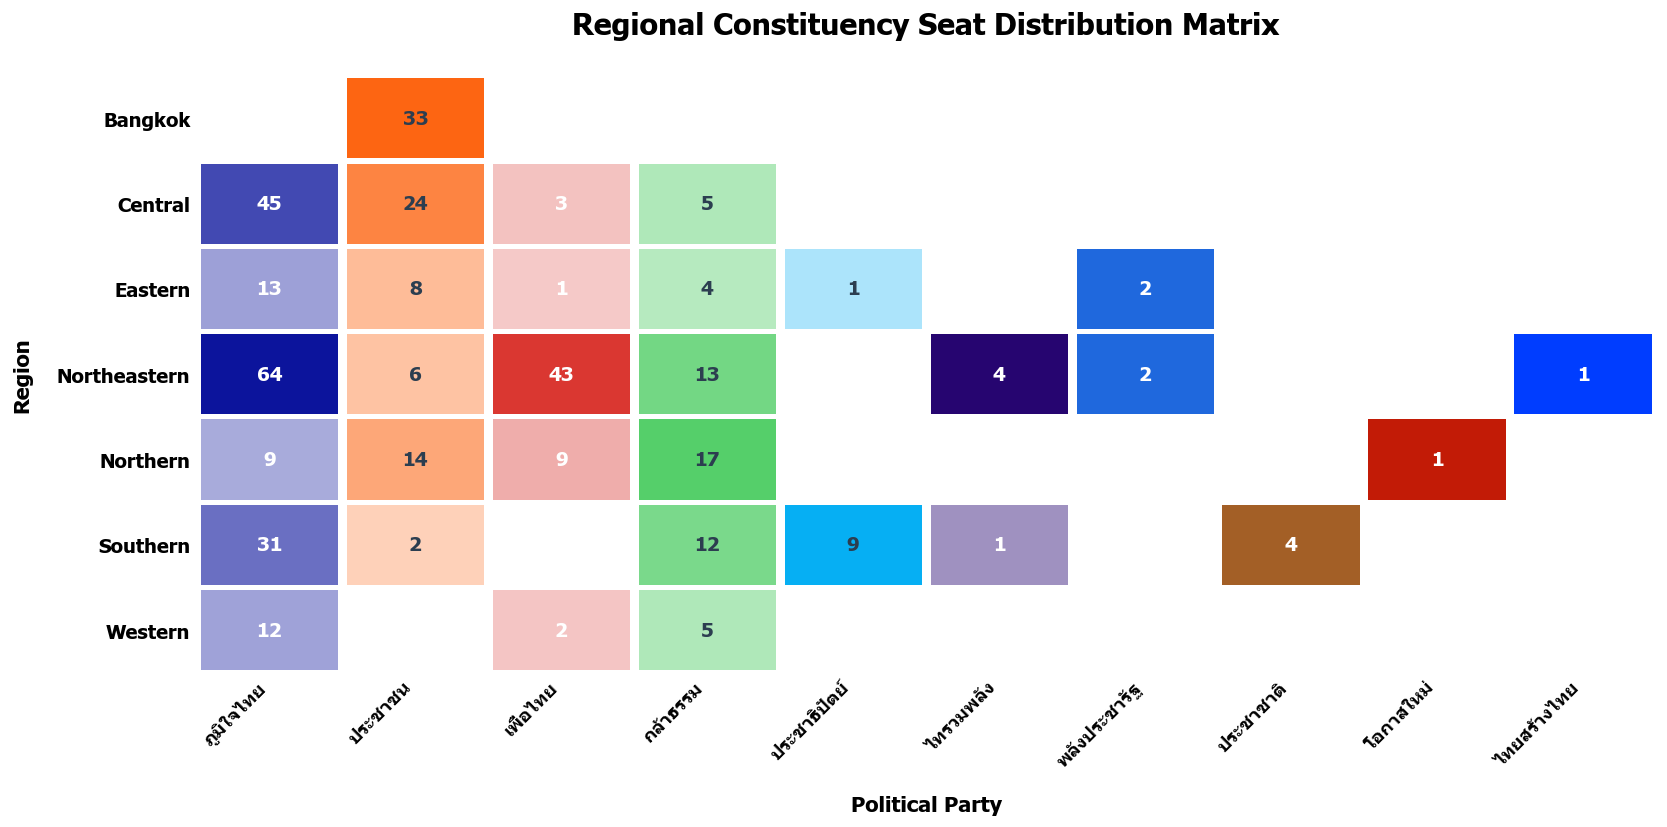

In [129]:
df_winners = df_cand_full[df_cand_full['mp_app_rank'] == 1].copy()
if 'region' not in df_winners.columns:
    df_winners = df_winners.merge(df_valid_cons[['cons_id','region']], on='cons_id', how='left')

heatmap_data = df_winners.groupby(['region','party_name']).size().unstack(fill_value=0)
top_parties  = heatmap_data.sum().sort_values(ascending=False).index
heatmap_data = heatmap_data[top_parties].sort_index(ascending=False)

regions_list = list(heatmap_data.index)
parties_list = list(heatmap_data.columns)
n_rows = len(regions_list)
n_cols = len(parties_list)

BG  = "#ffffff"
GAP = 0.03

fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for col_i, party in enumerate(parties_list):
    base_color = party_colors.get(party, '#bdc3c7')
    base_rgba  = np.array(to_rgba(base_color))
    col_max    = heatmap_data[party].max()

    for row_i, region in enumerate(regions_list):
        value = heatmap_data.loc[region, party]

        if value <= 0:
            facecolor = BG
            text = ''
        else:
            intensity  = value / col_max if col_max > 0 else 0
            cell_rgba  = base_rgba.copy()
            cell_rgba[3] = 0.25 + 0.75 * intensity
            facecolor  = cell_rgba
            text = str(int(value))

        rect = mpatches.Rectangle(
            (col_i + GAP, row_i + GAP), 1 - 2*GAP, 1 - 2*GAP,
            facecolor=facecolor, edgecolor='none', linewidth=0, zorder=2
        )
        ax.add_patch(rect)

        if text:
            luminance  = 0.299*base_rgba[0] + 0.587*base_rgba[1] + 0.114*base_rgba[2]
            text_color = 'white' if luminance < 0.5 else '#2c3e50'
            ax.text(col_i + 0.5, row_i + 0.5, text,
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color=text_color, zorder=3)

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect('auto')
ax.autoscale(False)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_xticklabels(parties_list, rotation=45, ha='right', fontsize=11, fontweight='bold')
ax.set_yticklabels(regions_list, rotation=0, fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='both', length=0)
for spine in ax.spines.values(): spine.set_visible(False)

ax.set_title('Regional Constituency Seat Distribution Matrix', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Political Party', fontsize=13, fontweight='bold', labelpad=15)
ax.set_ylabel('Region', fontsize=13, fontweight='bold', labelpad=15)

plt.tight_layout()
plt.grid(False)
plt.savefig('1.6_constituency_matrix.png', dpi=120, facecolor=BG, bbox_inches='tight')
plt.show()

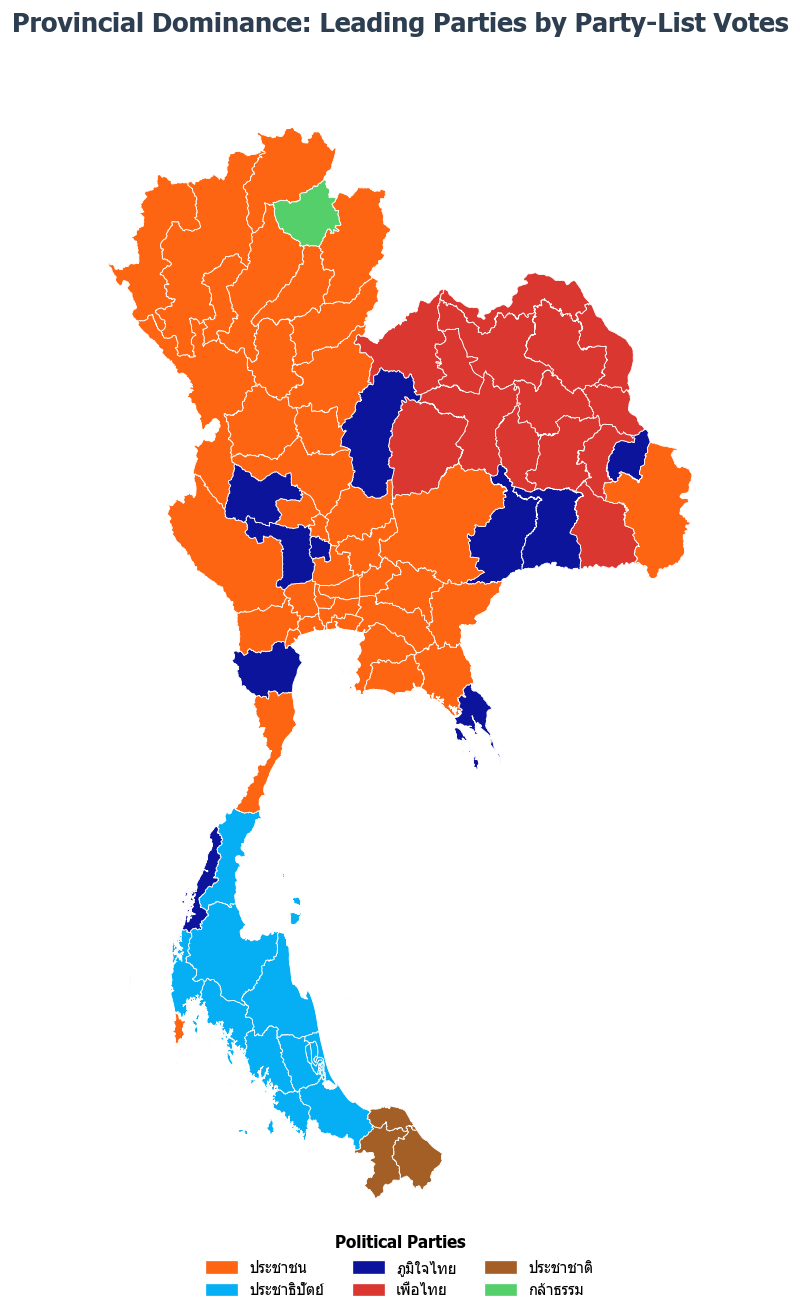

In [130]:
# provincial dominance

# 1. Data Preparation: Aggregate Party-List votes by province
if 'province' not in df_party_full.columns:
    df_party_prov = df_party_full.merge(df_cons_geo[['cons_id', 'province']], on='cons_id', how='left')
else:
    df_party_prov = df_party_full.copy()

prov_party_votes = df_party_prov.groupby(['province', 'party_name'])['party_list_vote'].sum().reset_index()
# Find the party with the maximum votes in each province
idx_max = prov_party_votes.groupby('province')['party_list_vote'].idxmax()
df_prov_winner = prov_party_votes.loc[idx_max].copy()
df_prov_winner['color'] = df_prov_winner['party_name'].map(party_colors).fillna('#bdc3c7')

# 2. Map Loading & Province Mapping
geojson_url = "https://raw.githubusercontent.com/cvibhagool/thailand-map/master/thailand-provinces.geojson"
th_map = gpd.read_file(geojson_url)

prov_mapping = {
    'Amnat Charoen': 'อำนาจเจริญ', 'Ang Thong': 'อ่างทอง', 'Bangkok Metropolis': 'กรุงเทพมหานคร', 
    'Buri Ram': 'บุรีรัมย์', 'Bueng Kan': 'บึงกาฬ', 'Chachoengsao': 'ฉะเชิงเทรา', 'Chai Nat': 'ชัยนาท', 
    'Chaiyaphum': 'ชัยภูมิ', 'Chanthaburi': 'จันทบุรี', 'Chiang Mai': 'เชียงใหม่', 
    'Chiang Rai': 'เชียงราย', 'Chon Buri': 'ชลบุรี', 'Chumphon': 'ชุมพร', 
    'Kalasin': 'กาฬสินธุ์', 'Kamphaeng Phet': 'กำแพงเพชร', 'Kanchanaburi': 'กาญจนบุรี', 
    'Khon Kaen': 'ขอนแก่น', 'Krabi': 'กระบี่', 'Lampang': 'ลำปาง', 
    'Lamphun': 'ลำพูน', 'Loei': 'เลย', 'Lop Buri': 'ลพบุรี', 
    'Mae Hong Son': 'แม่ฮ่องสอน', 'Maha Sarakham': 'มหาสารคาม', 'Mukdahan': 'มุกดาหาร', 
    'Nakhon Nayok': 'นครนายก', 'Nakhon Pathom': 'นครปฐม', 'Nakhon Phanom': 'นครพนม', 
    'Nakhon Ratchasima': 'นครราชสีมา', 'Nakhon Sawan': 'นครสวรรค์', 'Nakhon Si Thammarat': 'นครศรีธรรมราช', 
    'Nan': 'น่าน', 'Narathiwat': 'นราธิวาส', 'Nong Bua Lam Phu': 'หนองบัวลำภู', 
    'Nong Khai': 'หนองคาย', 'Nonthaburi': 'นนทบุรี', 'Pathum Thani': 'ปทุมธานี', 
    'Pattani': 'ปัตตานี', 'Phangnga': 'พังงา', 'Phatthalung (Songkhla Lake)': 'พัทลุง', 
    'Phatthalung': 'พัทลุง', 'Phayao': 'พะเยา', 'Phetchabun': 'เพชรบูรณ์', 
    'Phetchaburi': 'เพชรบุรี', 'Phichit': 'พิจิตร', 'Phitsanulok': 'พิษณุโลก', 
    'Phra Nakhon Si Ayutthaya': 'พระนครศรีอยุธยา', 'Phrae': 'แพร่', 'Phuket': 'ภูเก็ต', 
    'Prachin Buri': 'ปราจีนบุรี', 'Prachuap Khiri Khan': 'ประจวบคีรีขันธ์', 'Ranong': 'ระนอง', 
    'Ratchaburi': 'ราชบุรี', 'Rayong': 'ระยอง', 'Roi Et': 'ร้อยเอ็ด', 
    'Sa Kaeo': 'สระแก้ว', 'Sakon Nakhon': 'สกลนคร', 'Samut Prakan': 'สมุทรปราการ', 
    'Samut Sakhon': 'สมุทรสาคร', 'Samut Songkhram': 'สมุทรสงคราม', 'Saraburi': 'สระบุรี', 
    'Satun': 'สตูล', 'Si Sa Ket': 'ศรีสะเกษ', 'Sing Buri': 'สิงห์บุรี', 
    'Songkhla (Songkhla Lake)': 'สงขลา', 'Songkhla': 'สงขลา', 'Sukhothai': 'สุโขทัย', 
    'Suphan Buri': 'สุพรรณบุรี', 'Surat Thani': 'สุราษฎร์ธานี', 'Surin': 'สุรินทร์', 
    'Tak': 'ตาก', 'Trang': 'ตรัง', 'Trat': 'ตราด', 
    'Ubon Ratchathani': 'อุบลราชธานี', 'Udon Thani': 'อุดรธานี', 'Uthai Thani': 'อุทัยธานี', 
    'Uttaradit': 'อุตรดิตถ์', 'Yala': 'ยะลา', 'Yasothon': 'ยโสธร'
}

possible_cols = ['name', 'NAME_1', 'provinces', 'PROV_NAMT', 'th_name']
map_join_col = next((col for col in possible_cols if col in th_map.columns), th_map.columns[0])
th_map['clean_map_province'] = th_map[map_join_col].apply(lambda x: prov_mapping.get(x.strip(), x.strip()))

merged_map = th_map.merge(df_prov_winner, left_on='clean_map_province', right_on='province', how='left')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Tahoma'

fig, ax = plt.subplots(1, 1, figsize=(8, 11), facecolor='#ffffff')
merged_map.plot(color=merged_map['color'].fillna('#f0f3f4'), edgecolor='white', linewidth=0.5, ax=ax)
plt.title("Provincial Dominance: Leading Parties by Party-List Votes", 
          fontsize=16, fontweight='bold', pad=25, color='#2c3e50', x=0.5, loc='center')

ax.axis('off')

winning_parties = df_prov_winner.sort_values('party_list_vote', ascending=False)['party_name'].unique()
legend_patches = [mpatches.Patch(color=party_colors.get(p, '#bdc3c7'), label=p) for p in winning_parties]

ax.legend(handles=legend_patches, loc='lower center', 
          bbox_to_anchor=(0.5, -0.05),
          ncol=3,
          title='Political Parties', 
          title_fontproperties={'weight':'bold', 'size': 10},
          fontsize=9, frameon=False)

plt.tight_layout()
# plt.savefig('1.7 provincial dominance.png', dpi=120)
plt.show()

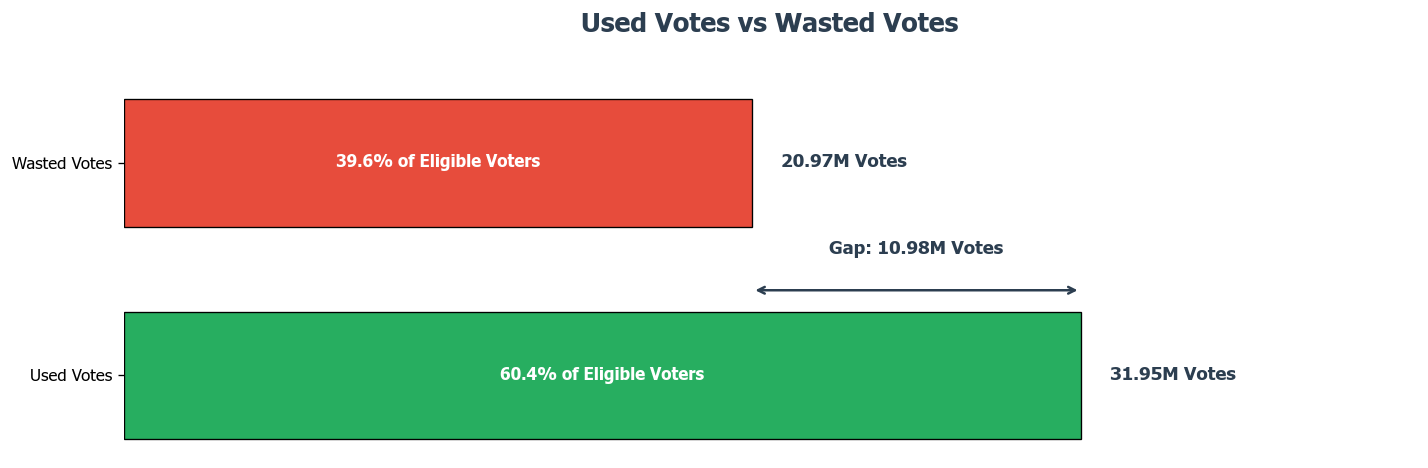

In [131]:
# used votes vs wates vote
valid_total = total_valid
ghost_total = total_no_show + total_invalid + total_no_vote
gap = valid_total - ghost_total

categories = ['Used Votes', 'Wasted Votes'] # คะแนนที่ถูกใช้ vs คะแนนที่สูญเปล่า
values = [valid_total, ghost_total]
colors = ['#27AE60', '#E74C3C'] 

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Tahoma'
BG_COLOR = '#ffffff'

fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(categories, values, color=colors, edgecolor='black', linewidth=0.8, height=0.6)

max_val = max(values)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + (max_val * 0.03), i, f'{width/1e6:.2f}M Votes', 
            va='center', fontsize=11, fontweight='bold', color='#2c3e50')
    share = (width / total_eligible) * 100
    ax.text(width/2, i, f'{share:.1f}% of Eligible Voters', 
            ha='center', va='center', color='white', fontweight='bold', fontsize=10)

ax.annotate('', xy=(ghost_total, 0.4), xytext=(valid_total, 0.4),
             arrowprops=dict(arrowstyle='<->', color='#2c3e50', lw=1.5))
ax.text((valid_total + ghost_total)/2, 0.55, f'Gap: {gap/1e6:.2f}M Votes', 
         ha='center', va='bottom', fontweight='bold', color='#2c3e50', fontsize=11)

plt.title('Used Votes vs Wasted Votes', 
          fontsize=16, fontweight='bold', pad=30, color='#2c3e50', x=0.5, loc='center')

ax.set_xlim(0, max_val * 1.35)
ax.xaxis.set_visible(False)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.subplots_adjust(left=0.3, right=0.8) 
plt.grid(False)
plt.tight_layout()
# plt.savefig('1.8 used votes vs wasted vote.png', dpi=120)
plt.show()

# Section 2: Pandas Project


In [132]:
#ข้อมูลจำนวนพรรค
df_party_overview.sort_values('party_no').head()

,id,party_no,name,abbr,color,logo_url
0,254,1,ไทยทรัพย์ทวี,ททว.,#f02d30,https://static-ectreport69.ect.go.th/data/part...
9,170,10,ทางเลือกใหม่,ทลม.,#026aec,https://static-ectreport69.ect.go.th/data/part...
10,173,11,เศรษฐกิจ,ศก,#f7c036,https://static-ectreport69.ect.go.th/data/part...
11,145,12,เสรีรวมไทย,สร.,#b49e31,https://static-ectreport69.ect.go.th/data/part...
12,255,13,รวมพลังประชาชน,รพปช,#2f368d,https://static-ectreport69.ect.go.th/data/part...


In [133]:
#ข้อมูลของการรายเขต ของแต่ละจังหวัด (ผลโหวต, จำนวนจุดเลือกตั้ง)
df_constituency.sort_values('cons_id').head()

,cons_id,cons_no,prov_id,total_vote_stations,registered_vote,zone
172,ACR_1,1,ACR,323,145524.0,"อำเภอเมืองอำนาจเจริญ, อำเภอหัวตะพาน"
173,ACR_2,2,ACR,352,157184.0,"อำเภอชานุมาน, อำเภอปทุมราชวงศา, อำเภอพนา, อำเภ..."
64,ATG_1,1,ATG,249,111666.0,"อำเภอเมืองอ่างทอง, อำเภอป่าโมก, อำเภอวิเศษชัยช..."
65,ATG_2,2,ATG,256,112423.0,"อำเภอไชโย, อำเภอโพธิ์ทอง, อำเภอแสวงหา, อำเภอวิ..."
59,AYA_1,1,AYA,239,140188.0,"อำเภอพระนครศรีอยุธยา, อำเภอบางบาล"


In [134]:
#ข้อมูลรายชื่อและเลขของผู้สมัคร แบ่งตามเขต
df_mp_candidate[df_mp_candidate['mp_app_party_id']==34]

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,image_url
0,KBI_1_1,1,34.0,นายสุวรรณ อินพรหม,https://static-ectreport69.ect.go.th/data/cand...
6,KBI_2_1,1,34.0,นายยุทธนา อ่าวลึกน้อย,https://static-ectreport69.ect.go.th/data/cand...
15,KBI_3_3,3,34.0,นายกุศล วะเจดีย์,https://static-ectreport69.ect.go.th/data/cand...
26,BKK_1_8,8,34.0,นายญาณกิตติ์ ห่วงทรัพย์,https://static-ectreport69.ect.go.th/data/cand...
41,BKK_2_5,5,34.0,นายเดวิด มกรพงศ์,https://static-ectreport69.ect.go.th/data/cand...
...,...,...,...,...,...
3457,UBN_7_5,5,34.0,นายเชิดศักดิ์ โภคกุลกานนท์,https://static-ectreport69.ect.go.th/data/cand...
3464,UBN_8_4,4,34.0,นางสาวจิตภินันท์ วงษ์ขันธ์,https://static-ectreport69.ect.go.th/data/cand...
3471,UBN_9_1,1,34.0,นายประภูศักดิ์ จินตะเวช,https://static-ectreport69.ect.go.th/data/cand...
3480,UBN_10_3,3,34.0,นายวัชรพล เชื้อคง,https://static-ectreport69.ect.go.th/data/cand...


In [135]:
#key is last name use to join data บ้านใหญ่
df_mp_candidate[['first_name', 'last_name']] = df_mp_candidate['mp_app_name'].str.split(' ', n=1, expand=True)
df_mp_candidate.drop(columns= 'image_url', inplace= True)
df_mp_candidate.head()

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,first_name,last_name
0,KBI_1_1,1,34.0,นายสุวรรณ อินพรหม,นายสุวรรณ,อินพรหม
1,KBI_1_2,2,63.0,นายกิตติ กิตติธรกุล,นายกิตติ,กิตติธรกุล
2,KBI_1_3,3,129.0,นายธนวัช ภูเก้าล้วน,นายธนวัช,ภูเก้าล้วน
3,KBI_1_4,4,1.0,นายวศิน สิริเกียรติกุล,นายวศิน,สิริเกียรติกุล
4,KBI_1_5,5,173.0,นายพิทักษ์ ภารา,นายพิทักษ์,ภารา


In [136]:
df_mp_candidate[df_mp_candidate['last_name']=='กิตติธรกุล']

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,first_name,last_name
1,KBI_1_2,2,63.0,นายกิตติ กิตติธรกุล,นายกิตติ,กิตติธรกุล


In [137]:
df_province #ข้อมูลภาพใหญ่รายจังหวัด

,province_id,prov_id,province,abbre_thai,eng,total_vote_stations,total_registered_vote,region
0,10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok
1,11,SPK,สมุทรปราการ,สป,SPK,1771,1126420,Central
2,12,NBI,นนทบุรี,นบ,NBI,1559,1094383,Central
3,13,PTE,ปทุมธานี,ปท,PTE,1493,1012760,Central
4,14,AYA,พระนครศรีอยุธยา,อย,AYA,1160,677848,Central
...,...,...,...,...,...,...,...,...
72,92,TRG,ตรัง,ตง,TRG,943,510403,Southern
73,93,PLG,พัทลุง,พท,PLG,806,422693,Southern
74,94,PTN,ปัตตานี,ปน,PTN,982,525674,Southern
75,95,YLA,ยะลา,ยล,YLA,708,395865,Southern


In [138]:
#ข้อมูลจำนวนพรรค
df_stats_party_clean = df_stats_party.copy()
df_stats_party_clean.head()

,party_id,party_vote,party_vote_percent,party_list_count,mp_app_vote,mp_app_vote_percent,first_mp_app_count
0,254,285497,0.82436,None,2440,0.00705,0
1,185,629628,1.81802,None,459,0.00133,0
2,244,294502,0.85036,None,653,0.00189,0
3,228,230307,0.66500,None,1205,0.00348,0
4,250,404166,1.16701,None,2638,0.00762,0


In [139]:
df_stats_cons_clean = df_stats_cons.copy()
df_stats_cons_clean.to_csv('perc.csv')

In [140]:
#key
url_df_bigdhouse = "https://github.com/book150243/DADS5001/raw/refs/heads/main/%E0%B8%95%E0%B8%A3%E0%B8%B0%E0%B8%81%E0%B8%B9%E0%B8%A5%E0%B8%9A%E0%B9%89%E0%B8%B2%E0%B8%99%E0%B9%83%E0%B8%AB%E0%B8%8D%E0%B9%88.xlsx"
df_bigdhouse = pd.read_excel(url_df_bigdhouse)
df_bigdhouse = df_bigdhouse.rename(columns={'ภาค':'region','จังหวัด':'province', 'สังกัดพรรค 2566':'party_2566', 'สังกัดพรรค 2569':'party_2569','บ้านใหญ่ย้ายพรรคหรือไม่':'Transfer_party', 'ตระกูลบ้านใหญ่':'last_name' })
df_bigdhouse['bighouse'] = "bighouse"
df_bigdhouse.head()

,region,province,last_name,party_2566,party_2569,Transfer_party,bighouse
0,กลาง,กรุงเทพ,คงอุดม,รวมไทยสร้างชาติ,รวมไทยสร้างชาติ,ไม่ย้าย,bighouse
1,กลาง,กรุงเทพ,ห่วงทรัพย์,เพื่อไทย,เพื่อไทย,ไม่ย้าย,bighouse
2,กลาง,กรุงเทพ,รัสมี,พลังประชารัฐ,เพื่อไทย,ย้าย,bighouse
3,กลาง,กรุงเทพ,มีนชัยนันท์,เพื่อไทย,เพื่อไทย,ไม่ย้าย,bighouse
4,กลาง,กรุงเทพ,มีนชัยนันท์,ประชาชน,ประชาชน,ไม่ย้าย,bighouse


In [141]:
df_cand_with_party_name = pd.merge(df_mp_candidate, df_party_overview, left_on= 'mp_app_party_id', right_on= 'id', how = 'left')
df_cand_with_party_name['name']

0           เพื่อไทย
1          ภูมิใจไทย
2            ประชาชน
3       ประชาธิปัตย์
4           เศรษฐกิจ
            ...     
3486       ภูมิใจไทย
3487        เพื่อไทย
3488        กล้าธรรม
3489         ประชาชน
3490     ไทยสร้างไทย
Name: name, Length: 3491, dtype: object

In [142]:
df_mp_and_bighouse = pd.merge(df_cand_with_party_name, df_bigdhouse, left_on= ['last_name','name'] , right_on= ['last_name','party_2569'], how = 'left')
df_mp_and_bighouse

,mp_app_id,mp_app_no,mp_app_party_id,mp_app_name,first_name,last_name,id,party_no,name,abbr,color,logo_url,region,province,party_2566,party_2569,Transfer_party,bighouse
0,KBI_1_1,1,34.0,นายสุวรรณ อินพรหม,นายสุวรรณ,อินพรหม,34.0,9,เพื่อไทย,พท.,#da3731,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
1,KBI_1_2,2,63.0,นายกิตติ กิตติธรกุล,นายกิตติ,กิตติธรกุล,63.0,37,ภูมิใจไทย,ภท.,#0c149c,https://static-ectreport69.ect.go.th/data/part...,ใต้,กระบี่,ภูมิใจไทย,ภูมิใจไทย,ไม่ย้าย,bighouse
2,KBI_1_3,3,129.0,นายธนวัช ภูเก้าล้วน,นายธนวัช,ภูเก้าล้วน,129.0,46,ประชาชน,ปชน,#fd6512,https://static-ectreport69.ect.go.th/data/part...,ใต้,กระบี่,ประชาธิปัตย์,ประชาชน,ย้าย,bighouse
3,KBI_1_4,4,1.0,นายวศิน สิริเกียรติกุล,นายวศิน,สิริเกียรติกุล,1.0,27,ประชาธิปัตย์,ปชป.,#06aff3,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
4,KBI_1_5,5,173.0,นายพิทักษ์ ภารา,นายพิทักษ์,ภารา,173.0,11,เศรษฐกิจ,ศก,#f7c036,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,UBN_11_3,3,63.0,นางสาวตวงทิพย์ จินตะเวช,นางสาวตวงทิพย์,จินตะเวช,63.0,37,ภูมิใจไทย,ภท.,#0c149c,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
3487,UBN_11_4,4,34.0,นางอุบล สิมมา,นางอุบล,สิมมา,34.0,9,เพื่อไทย,พท.,#da3731,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
3488,UBN_11_5,5,218.0,นายสมมาตร มะลิลา,นายสมมาตร,มะลิลา,218.0,42,กล้าธรรม,กธ,#55CF6A,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN
3489,UBN_11_6,6,129.0,นายธีรศักดิ์ วีระจินตวงศ์,นายธีรศักดิ์,วีระจินตวงศ์,129.0,46,ประชาชน,ปชน,#fd6512,https://static-ectreport69.ect.go.th/data/part...,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
# Ensure df_bigdhouse is defined
url_df_bigdhouse = "https://github.com/book150243/DADS5001/raw/refs/heads/main/%E0%B8%95%E0%B8%A3%E0%B8%B0%E0%B8%81%E0%B8%B9%E0%B8%A5%E0%B8%9A%E0%B9%89%E0%B8%B2%E0%B8%99%E0%B9%83%E0%B8%AB%E0%B8%8D%E0%B9%88.xlsx"
df_bigdhouse = pd.read_excel(url_df_bigdhouse)
df_bigdhouse = df_bigdhouse.rename(columns={'ภาค':'region','จังหวัด':'province', 'สังกัดพรรค 2566':'party_2566', 'สังกัดพรรค 2569':'party_2569','บ้านใหญ่ย้ายพรรคหรือไม่':'Transfer_party', 'ตระกูลบ้านใหญ่':'last_name' })
df_bigdhouse['bighouse'] = "bighouse"

# Ensure df_mp_candidate has 'last_name'
df_mp_candidate[['first_name', 'last_name']] = df_mp_candidate['mp_app_name'].str.split(' ', n=1, expand=True)

# Join with party overview
df_cand_with_party_name = pd.merge(df_mp_candidate, df_party_overview, left_on='mp_app_party_id', right_on='id', how='left')

# Create the bighouse mapping dataframe
df_mp_and_bighouse = pd.merge(df_cand_with_party_name, df_bigdhouse, left_on=['last_name','name'], right_on=['last_name','party_2569'], how='left')

# Merge candidate stats with constituency summary to get prov_id
df_cal_score_per_candidate = pd.merge(
    df_stats_cons_cand,
    df_stats_cons_summary[['cons_id', 'turn_out']],
    on='cons_id',
    how='left'
)

# Ensure prov_id is retrieved from df_constituencies
df_cal_score_per_candidate = pd.merge(
    df_cal_score_per_candidate,
    df_constituencies[['cons_id', 'prov_id']],
    on='cons_id',
    how='left'
)

# Merge with bighouse info
df_cal_score_per_candidate_bighouse = pd.merge(
    df_cal_score_per_candidate,
    df_mp_and_bighouse[['mp_app_id', 'mp_app_party_id', 'bighouse']],
    left_on=['mp_app_id','party_id'],
    right_on=['mp_app_id','mp_app_party_id'],
    how='left'
)

df_cal_score_per_candidate_bighouse['bighouse'] = df_cal_score_per_candidate_bighouse['bighouse'].fillna("not_bighouse")
df_cal_score_per_candidate_bighouse['is_winner'] = (df_cal_score_per_candidate_bighouse['mp_app_rank'] == 1).astype(int)

# Final merge with province info
df_cal_score_per_candidate_bighouse = pd.merge(
    df_cal_score_per_candidate_bighouse,
    df_province[['prov_id', 'province', 'region']],
    on='prov_id',
    how='left'
)

df_cal_score_per_candidate_bighouse.to_csv('check_2.csv')
print('Execution completed successfully.')

Execution completed successfully.


In [144]:
df_cal_margin = df_cal_score_per_candidate_bighouse

df_cal_margin['mp_app_vote_portion'] = df_cal_margin['mp_app_vote_percent']/100
df_cal_margin['vote_portion^2'] = df_cal_margin['mp_app_vote_portion']**2

df_cal_margin = pd.merge(df_cal_margin, df_constituency, left_on= 'cons_id', right_on = 'cons_id', how = 'left')
df_cal_margin = pd.merge(df_cal_margin, df_province, left_on= 'prov_id_y', right_on = 'prov_id', how = 'left')

mapping_bh = {'bighouse': 1, 'not_bighouse': 0}

df_cal_margin['bighouse_no'] = df_cal_margin['bighouse'].map(mapping_bh)
df_cal_margin

,mp_app_id,mp_app_vote,mp_app_vote_percent,mp_app_rank,party_id,cons_id,turn_out,prov_id_x,mp_app_party_id,bighouse,...,zone,province_id,prov_id,province_y,abbre_thai,eng,total_vote_stations_y,total_registered_vote,region_y,bighouse_no
0,BKK_1_5,32564,44.39294,1,129.0,BKK_1,78449,BKK,129.0,not_bighouse,...,"เขตพระนคร, เขตดุสิต (ยกเว้นถนนนครไชยศรี), เขตบ...",10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,0
1,BKK_1_9,14018,19.11007,2,1.0,BKK_1,78449,BKK,1.0,not_bighouse,...,"เขตพระนคร, เขตดุสิต (ยกเว้นถนนนครไชยศรี), เขตบ...",10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,0
2,BKK_1_1,13661,18.62339,3,63.0,BKK_1,78449,BKK,63.0,not_bighouse,...,"เขตพระนคร, เขตดุสิต (ยกเว้นถนนนครไชยศรี), เขตบ...",10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,0
3,BKK_1_8,5761,7.85370,4,34.0,BKK_1,78449,BKK,34.0,bighouse,...,"เขตพระนคร, เขตดุสิต (ยกเว้นถนนนครไชยศรี), เขตบ...",10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,1
4,BKK_1_6,1983,2.70333,5,229.0,BKK_1,78449,BKK,229.0,not_bighouse,...,"เขตพระนคร, เขตดุสิต (ยกเว้นถนนนครไชยศรี), เขตบ...",10,BKK,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,NWT_5_5,31022,38.47642,2,218.0,NWT_5,84877,NWT,218.0,not_bighouse,...,"อำเภอบาเจาะ, อำเภอรือเสาะ, อำเภอศรีสาคร",96,NWT,นราธิวาส,นธ,NWT,1086,597044,Southern,0
3487,NWT_5_6,4132,5.12490,3,129.0,NWT_5,84877,NWT,129.0,not_bighouse,...,"อำเภอบาเจาะ, อำเภอรือเสาะ, อำเภอศรีสาคร",96,NWT,นราธิวาส,นธ,NWT,1086,597044,Southern,0
3488,NWT_5_2,1522,1.88773,4,63.0,NWT_5,84877,NWT,63.0,not_bighouse,...,"อำเภอบาเจาะ, อำเภอรือเสาะ, อำเภอศรีสาคร",96,NWT,นราธิวาส,นธ,NWT,1086,597044,Southern,0
3489,NWT_5_3,878,1.08898,5,1.0,NWT_5,84877,NWT,1.0,not_bighouse,...,"อำเภอบาเจาะ, อำเภอรือเสาะ, อำเภอศรีสาคร",96,NWT,นราธิวาส,นธ,NWT,1086,597044,Southern,0


In [145]:
#ทำ Table ภาพรวม
# Ensure prov_id is present by merging with df_constituencies first
df_overview_vote = pd.merge(df_stats_cons_clean, df_constituencies[['cons_id', 'prov_id']], on='cons_id', how='left')
df_overview_vote = pd.merge(df_overview_vote, df_province, on='prov_id', how='left')
df_overview_vote['Thailand'] = 'Thailand'
display(df_overview_vote.head())

,cons_id,turn_out,percent_turn_out,valid_votes,invalid_votes,blank_votes,party_list_turn_out,party_list_percent_turn_out,party_list_valid_votes,party_list_invalid_votes,...,pause_report,prov_id,province_id,province,abbre_thai,eng,total_vote_stations,total_registered_vote,region,Thailand
0,BKK_0,0,0.00000,0,0,0,0,0.00000,0,0,...,False,BKK,10,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,Thailand
1,BKK_1,78449,60.14967,73354,1083,4012,78155,59.92425,74515,1590,...,False,BKK,10,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,Thailand
2,BKK_2,84672,62.03940,78713,1319,4640,84550,61.95002,80804,1432,...,False,BKK,10,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,Thailand
3,BKK_3,77999,63.63214,72671,1353,3975,78327,63.89972,75007,1381,...,False,BKK,10,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,Thailand
4,BKK_4,74760,57.75069,70338,1370,3052,74571,57.60469,71263,1586,...,False,BKK,10,กรุงเทพมหานคร,กทม,BKK,6757,4502458,Bangkok,Thailand


# กราฟเทียบสัดส่วนการได้เก้าอี้ของ สส กลุ่มที่เป็น bighouse และไม่เป็น bighouse

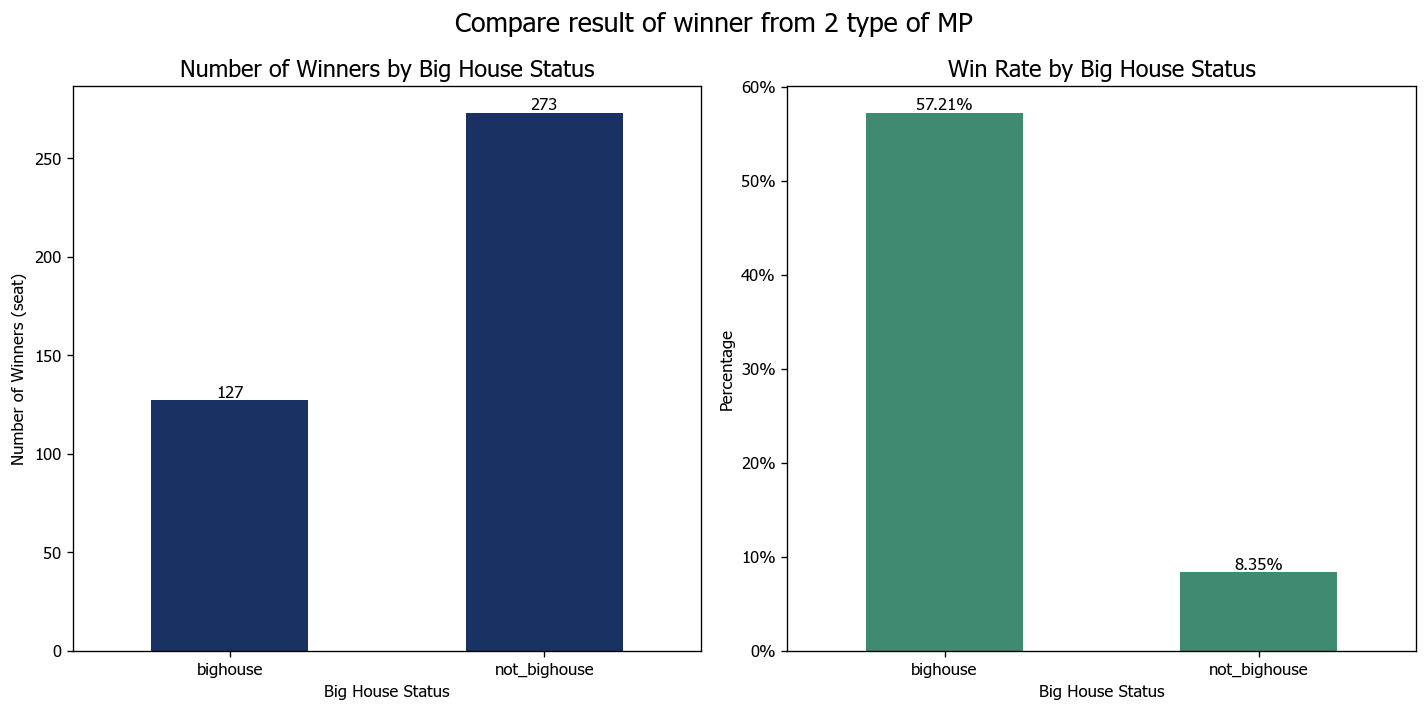

In [146]:
import matplotlib.ticker as mticker

check_winner_graph= pd.pivot_table(
    df_cal_score_per_candidate_bighouse,
    values = 'is_winner',
    index = 'bighouse',
    aggfunc = {
        'is_winner' : 'sum'}
)

count_bighouse = pd.pivot_table(
    df_cal_score_per_candidate_bighouse,
    values = ['mp_app_id','is_winner'],
    index = ['bighouse'],
    aggfunc = {
        'mp_app_id': 'count',
        'is_winner' : 'sum',
    }
)

count_bighouse = count_bighouse.reset_index(None)

count_bighouse['win_rate'] = (count_bighouse['is_winner'] / count_bighouse['mp_app_id']) * 100


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Compare result of winner from 2 type of MP', fontsize=16)

check_winner_graph.plot(kind='bar', ax=axes[0], color='#1A3263', legend = False)
axes[0].set_title('Number of Winners by Big House Status', fontsize=14)
axes[0].set_ylabel('Number of Winners (seat)')
axes[0].set_xlabel('Big House Status')
axes[0].tick_params(axis='x', rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

count_bighouse.set_index('bighouse')['win_rate'].plot(kind='bar', ax=axes[1], color='#408A71', label='Win Rate %', legend= False)
axes[1].set_title('Win Rate by Big House Status', fontsize=14)
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('Big House Status')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

figure x.x show the winner MP on each constuetency in Thailand.

จากรูปเราจะเห็นว่า สส ผู้ที่มีส่วนเกี่ยวข้องกับ bighouse จะมีจำนวนคนชนะน้อยกว่า สส ผู้ที่ไม่เกี่ยวข้องกับ bighouse แต่ถ้าดูในสัดส่วนจะเห็นได้ชัดว่าสัดส่วนของจำนวนผู้ที่ชนะแล้วเกี่ยวข้องกับ bighouse นั้นจะอยู่ที่ 54.21% ซึ่งสูงกว่าผู้ที่ไม่เกี่ยวกับ bighouse มาก ทำให้เห็นได้ว่าการเป็น สส ที่เกี่ยวข้องกับบ้านใหญ่จะมีโอกาสชนะถ้าเทียบกับการเป็น สส ที่ไม่เกี่ยวข้องกับบ้านใหญ่

# กราฟจำนวนผู้ชนะในแต่ละภูมิภาคแบ่งตามผู้สมัคร สส ที่เกี่ยวข้องกับบ้านใหญ่และไม่เกี่ยวข้อง

# กราฟเทียบจำนวนของ สส bighouse กับ สส ที่ไม่เป็น bighouse ของพรรค top5

In [147]:
import matplotlib.ticker as mticker

# Filter winners
df_check_winner = df_cal_margin[df_cal_margin["mp_app_rank"]==1].copy()

# Ensure party name is present by merging with df_party_overview
if 'name' not in df_check_winner.columns:
    df_check_winner = df_check_winner.merge(df_party_overview[['id', 'name']], left_on='party_id', right_on='id', how='left')

df_check_winner_pivot = pd.pivot_table(
    df_check_winner,
    values = ['bighouse','bighouse_no'],
    index = 'name',
    aggfunc = {
        'bighouse_no':'sum',
        'bighouse' : 'count'
    }
)
df_check_winner_pivot.reset_index(inplace= True)
df_check_winner_pivot.sort_values('bighouse', ascending= False, inplace= True)
df_check_winner_pivot = df_check_winner_pivot.rename(columns={'name':'party','bighouse':'Member of the House of Representatives','bighouse_no':'Member of the House of Representatives from bighouse'})
df_check_winner_pivot['Member of the House of Representatives not from bighouse'] = df_check_winner_pivot['Member of the House of Representatives'] - df_check_winner_pivot['Member of the House of Representatives from bighouse']
top_5_party_seat = df_check_winner_pivot.iloc[:,[0,2,3]].head()
top_5_party_seat = top_5_party_seat.set_index('party')

# Percentage Calculation
df_check_winner_pivot_perc = df_check_winner_pivot.copy()
target_cols = df_check_winner_pivot_perc.iloc[:, 2:4]
row_sums = target_cols.sum(axis=1)

df_check_winner_pivot_perc.iloc[:, 2:4] = target_cols.div(row_sums, axis=0) * 100
dis_df_check_winner_pivot_perc = df_check_winner_pivot_perc.iloc[:,[0,2,3]].set_index('party').head()
dis_df_check_winner_pivot_perc = dis_df_check_winner_pivot_perc.rename(columns={'Member of the House of Representatives from bighouse':'% MP bighouse','Member of the House of Representatives not from bighouse':'% MP not bighouse'})

print("MP number who get a seat\n")
display(top_5_party_seat.rename(columns={'Member of the House of Representatives from bighouse':'MP bighouse','Member of the House of Representatives not from bighouse':'MP not bighouse'}))
print("\n")
display(dis_df_check_winner_pivot_perc.style.format({'% MP bighouse':'{:.2f}%','% MP not bighouse':'{:.2f}%'}))

MP number who get a seat



,MP bighouse,MP not bighouse
party,,
ภูมิใจไทย,74,100
ประชาชน,3,84
เพื่อไทย,24,34
กล้าธรรม,19,37
ประชาธิปัตย์,4,6


,% MP bighouse,% MP not bighouse
party,,
ภูมิใจไทย,42.53%,57.47%
ประชาชน,3.45%,96.55%
เพื่อไทย,41.38%,58.62%
กล้าธรรม,33.93%,66.07%
ประชาธิปัตย์,40.00%,60.00%


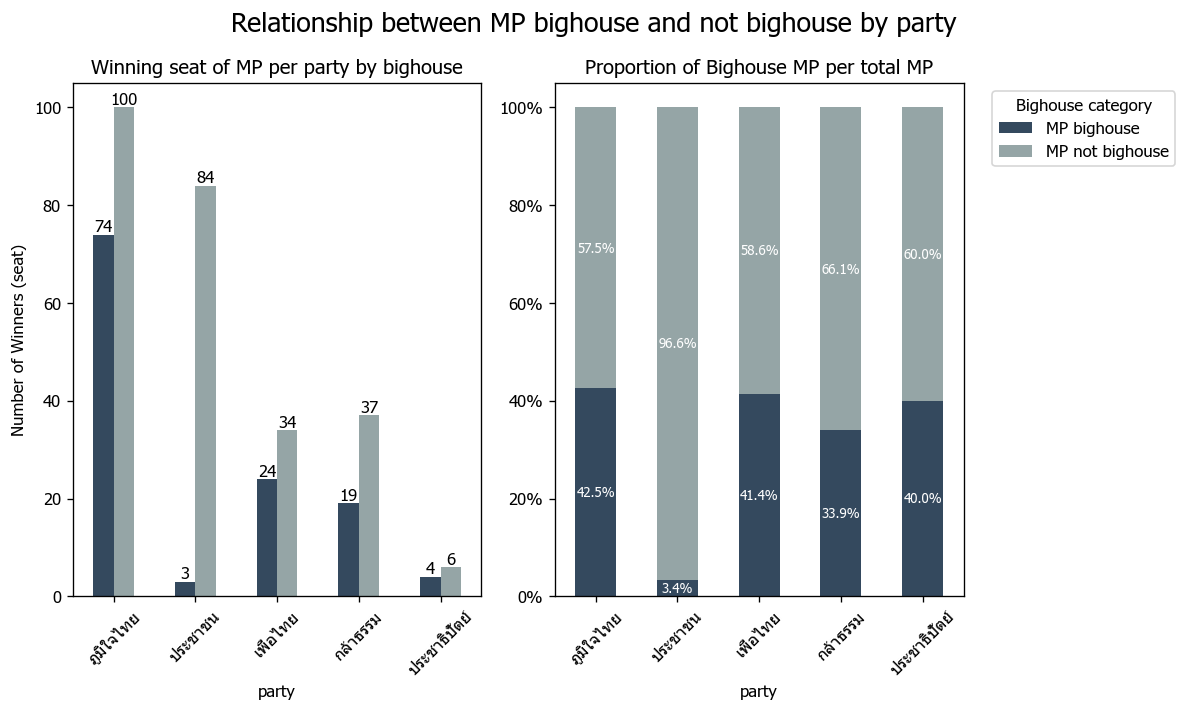

In [148]:
fig, axes = plt.subplots(1,2, figsize = (16, 14))
fig.suptitle('Relationship between MP bighouse and not bighouse by party', fontsize =16)

top_5_party_seat.plot(kind = "bar",figsize = (10,6),ax= axes[0], color = ['#34495e', '#95a5a6'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation= 45)
axes[0].get_legend().remove()
axes[0].set_ylabel('Number of Winners (seat)')
axes[0].set_title('Winning seat of MP per party by bighouse')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt = '%d',label_type='edge')

dis_df_check_winner_pivot_perc.plot(kind='bar', stacked=True, figsize=(10, 6),ax= axes[1], color=['#34495e', '#95a5a6'])
axes[1].legend(title = 'Bighouse category', labels=['MP bighouse', 'MP not bighouse'], bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_title('Proportion of Bighouse MP per total MP')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

for container in axes[1].containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    axes[1].bar_label(container, labels=labels, label_type='center', color='white', fontsize=8)

plt.tight_layout()
plt.show()

# กราฟ bighouse ราย region ดูตามพรรค

In [149]:
# Filter for winners and ensure necessary columns exist
df_winners = df_cal_score_per_candidate_bighouse[df_cal_score_per_candidate_bighouse['is_winner'] == 1].copy()

# Ensure party name is attached
if 'name' not in df_winners.columns:
    df_winners = df_winners.merge(df_party_overview[['id', 'name']], left_on='party_id', right_on='id', how='left')

# Use 'region' instead of 'region_y' to match the column name in df_cal_score_per_candidate_bighouse
df_winning_candidates_aggregated = df_winners.groupby(['region', 'name', 'bighouse'])['is_winner'].sum().reset_index()
df_winning_candidates_aggregated = df_winning_candidates_aggregated.rename(columns={'is_winner': 'winning_seats'})

display(df_winning_candidates_aggregated.head())

,region,name,bighouse,winning_seats
0,Bangkok,ประชาชน,bighouse,1
1,Bangkok,ประชาชน,not_bighouse,32
2,Central,กล้าธรรม,bighouse,2
3,Central,กล้าธรรม,not_bighouse,3
4,Central,ประชาชน,bighouse,1


In [150]:
unique_regions = df_winning_candidates_aggregated['region'].unique()

pivoted_data_by_region = {}

for region in unique_regions:
    region_data = df_winning_candidates_aggregated[
        df_winning_candidates_aggregated['region'] == region
    ]

    pivot_data = region_data.pivot_table(
        index='name',
        columns='bighouse',
        values='winning_seats',
        fill_value=0
    )
    pivoted_data_by_region[region] = pivot_data

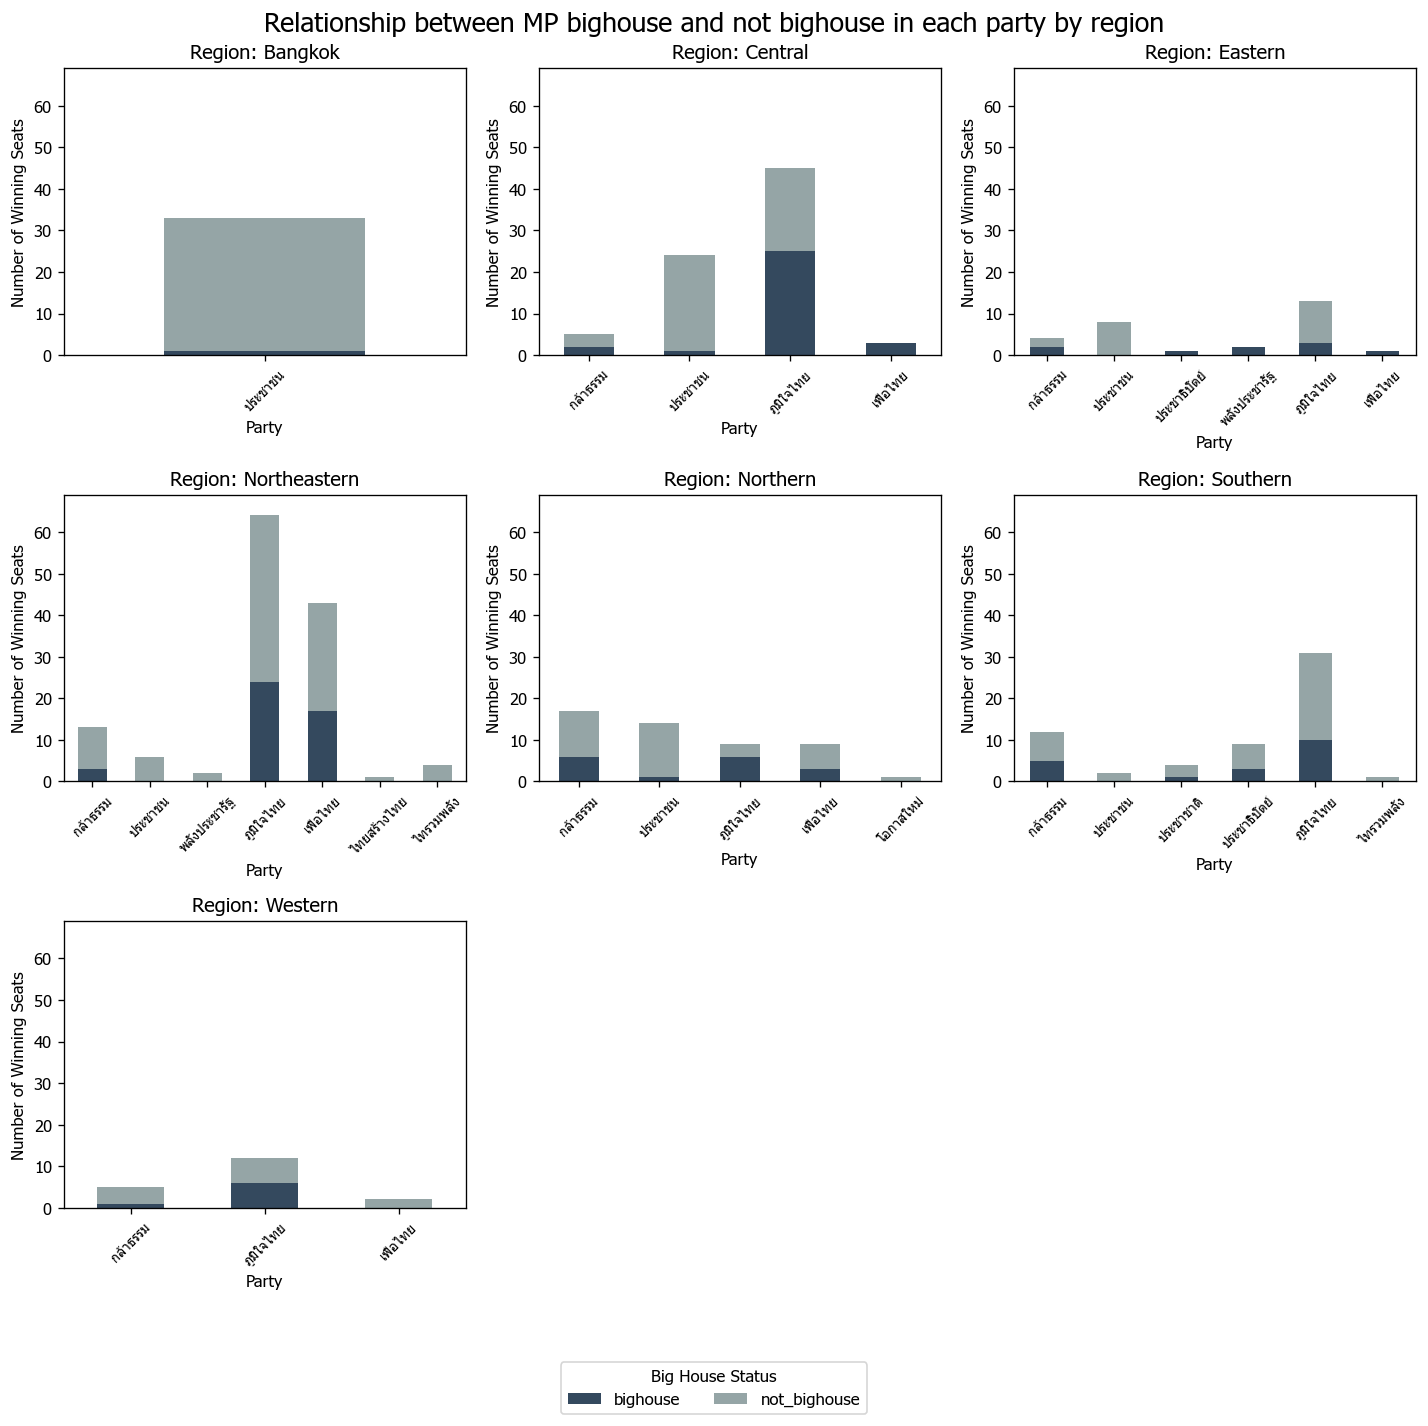

In [151]:
num_regions = len(unique_regions)
num_cols = 3
num_rows = (num_regions + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4), squeeze=False)
axes = axes.flatten()
fig.suptitle('Relationship between MP bighouse and not bighouse in each party by region', fontsize =16)

global_max_winning_seats = 0
for region_data in pivoted_data_by_region.values():
    global_max_winning_seats = max(global_max_winning_seats, region_data.sum(axis=1).max())

handles, labels = [], []

for i, region in enumerate(unique_regions):
    ax = axes[i]
    data = pivoted_data_by_region[region]

    if i == 0:
        plot_data = data.plot(kind='bar', ax=ax, stacked = True, color=['#34495e', '#95a5a6'])
        handles, labels = plot_data.get_legend_handles_labels()
    else:
        data.plot(kind='bar', ax=ax, stacked = True, color=['#34495e', '#95a5a6'])

    ax.set_title(f'Region: {region}', fontsize=12)
    ax.set_xlabel('Party', fontsize=10)
    ax.set_ylabel('Number of Winning Seats', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylim(0, global_max_winning_seats + 5)
    ax.get_legend().remove()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.legend(handles, labels, loc='lower center', title='Big House Status', ncol=len(labels), bbox_to_anchor=(0.5, 0.0),
           bbox_transform=fig.transFigure)


plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [152]:
for region in unique_regions:
    print(f'------------------------------------------------------------\n\n{region}')
    data = pivoted_data_by_region[region]
    data['total_seats'] = data['bighouse'] + data['not_bighouse']
    # Avoid division by zero for parties with no seats
    data['bighouse_proportion'] = data.apply(lambda row: (row['bighouse'] / row['total_seats'])*100 if row['total_seats'] > 0 else 0, axis=1)
    display(data.style.format({'bighouse_proportion':'{:.2f}%', 'bighouse': '{:.0f}', 'not_bighouse': '{:.0f}', 'total_seats': '{:.0f}'}))

------------------------------------------------------------

Bangkok


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
ประชาชน,1,32,33,3.03%


------------------------------------------------------------

Central


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,2,3,5,40.00%
ประชาชน,1,23,24,4.17%
ภูมิใจไทย,25,20,45,55.56%
เพื่อไทย,3,0,3,100.00%


------------------------------------------------------------

Eastern


...

bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,6,11,17,35.29%
ประชาชน,1,13,14,7.14%
ภูมิใจไทย,6,3,9,66.67%
เพื่อไทย,3,6,9,33.33%
โอกาสใหม่,0,1,1,0.00%


------------------------------------------------------------

Southern


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,5,7,12,41.67%
ประชาชน,0,2,2,0.00%
ประชาชาติ,1,3,4,25.00%
ประชาธิปัตย์,3,6,9,33.33%
ภูมิใจไทย,10,21,31,32.26%
ไทรวมพลัง,0,1,1,0.00%


------------------------------------------------------------

Western


bighouse,bighouse,not_bighouse,total_seats,bighouse_proportion
name,,,,
กล้าธรรม,1,4,5,20.00%
ภูมิใจไทย,6,6,12,50.00%
เพื่อไทย,0,2,2,0.00%


,Region,Total Bighouse Seat,Total Bighouse Losers,Total Bighouse Candidates
0,Bangkok,1,12,13
1,Central,31,13,44
2,Eastern,9,6,15
3,Northeastern,44,34,78
4,Northern,16,15,31
5,Southern,19,13,32
6,Western,7,2,9


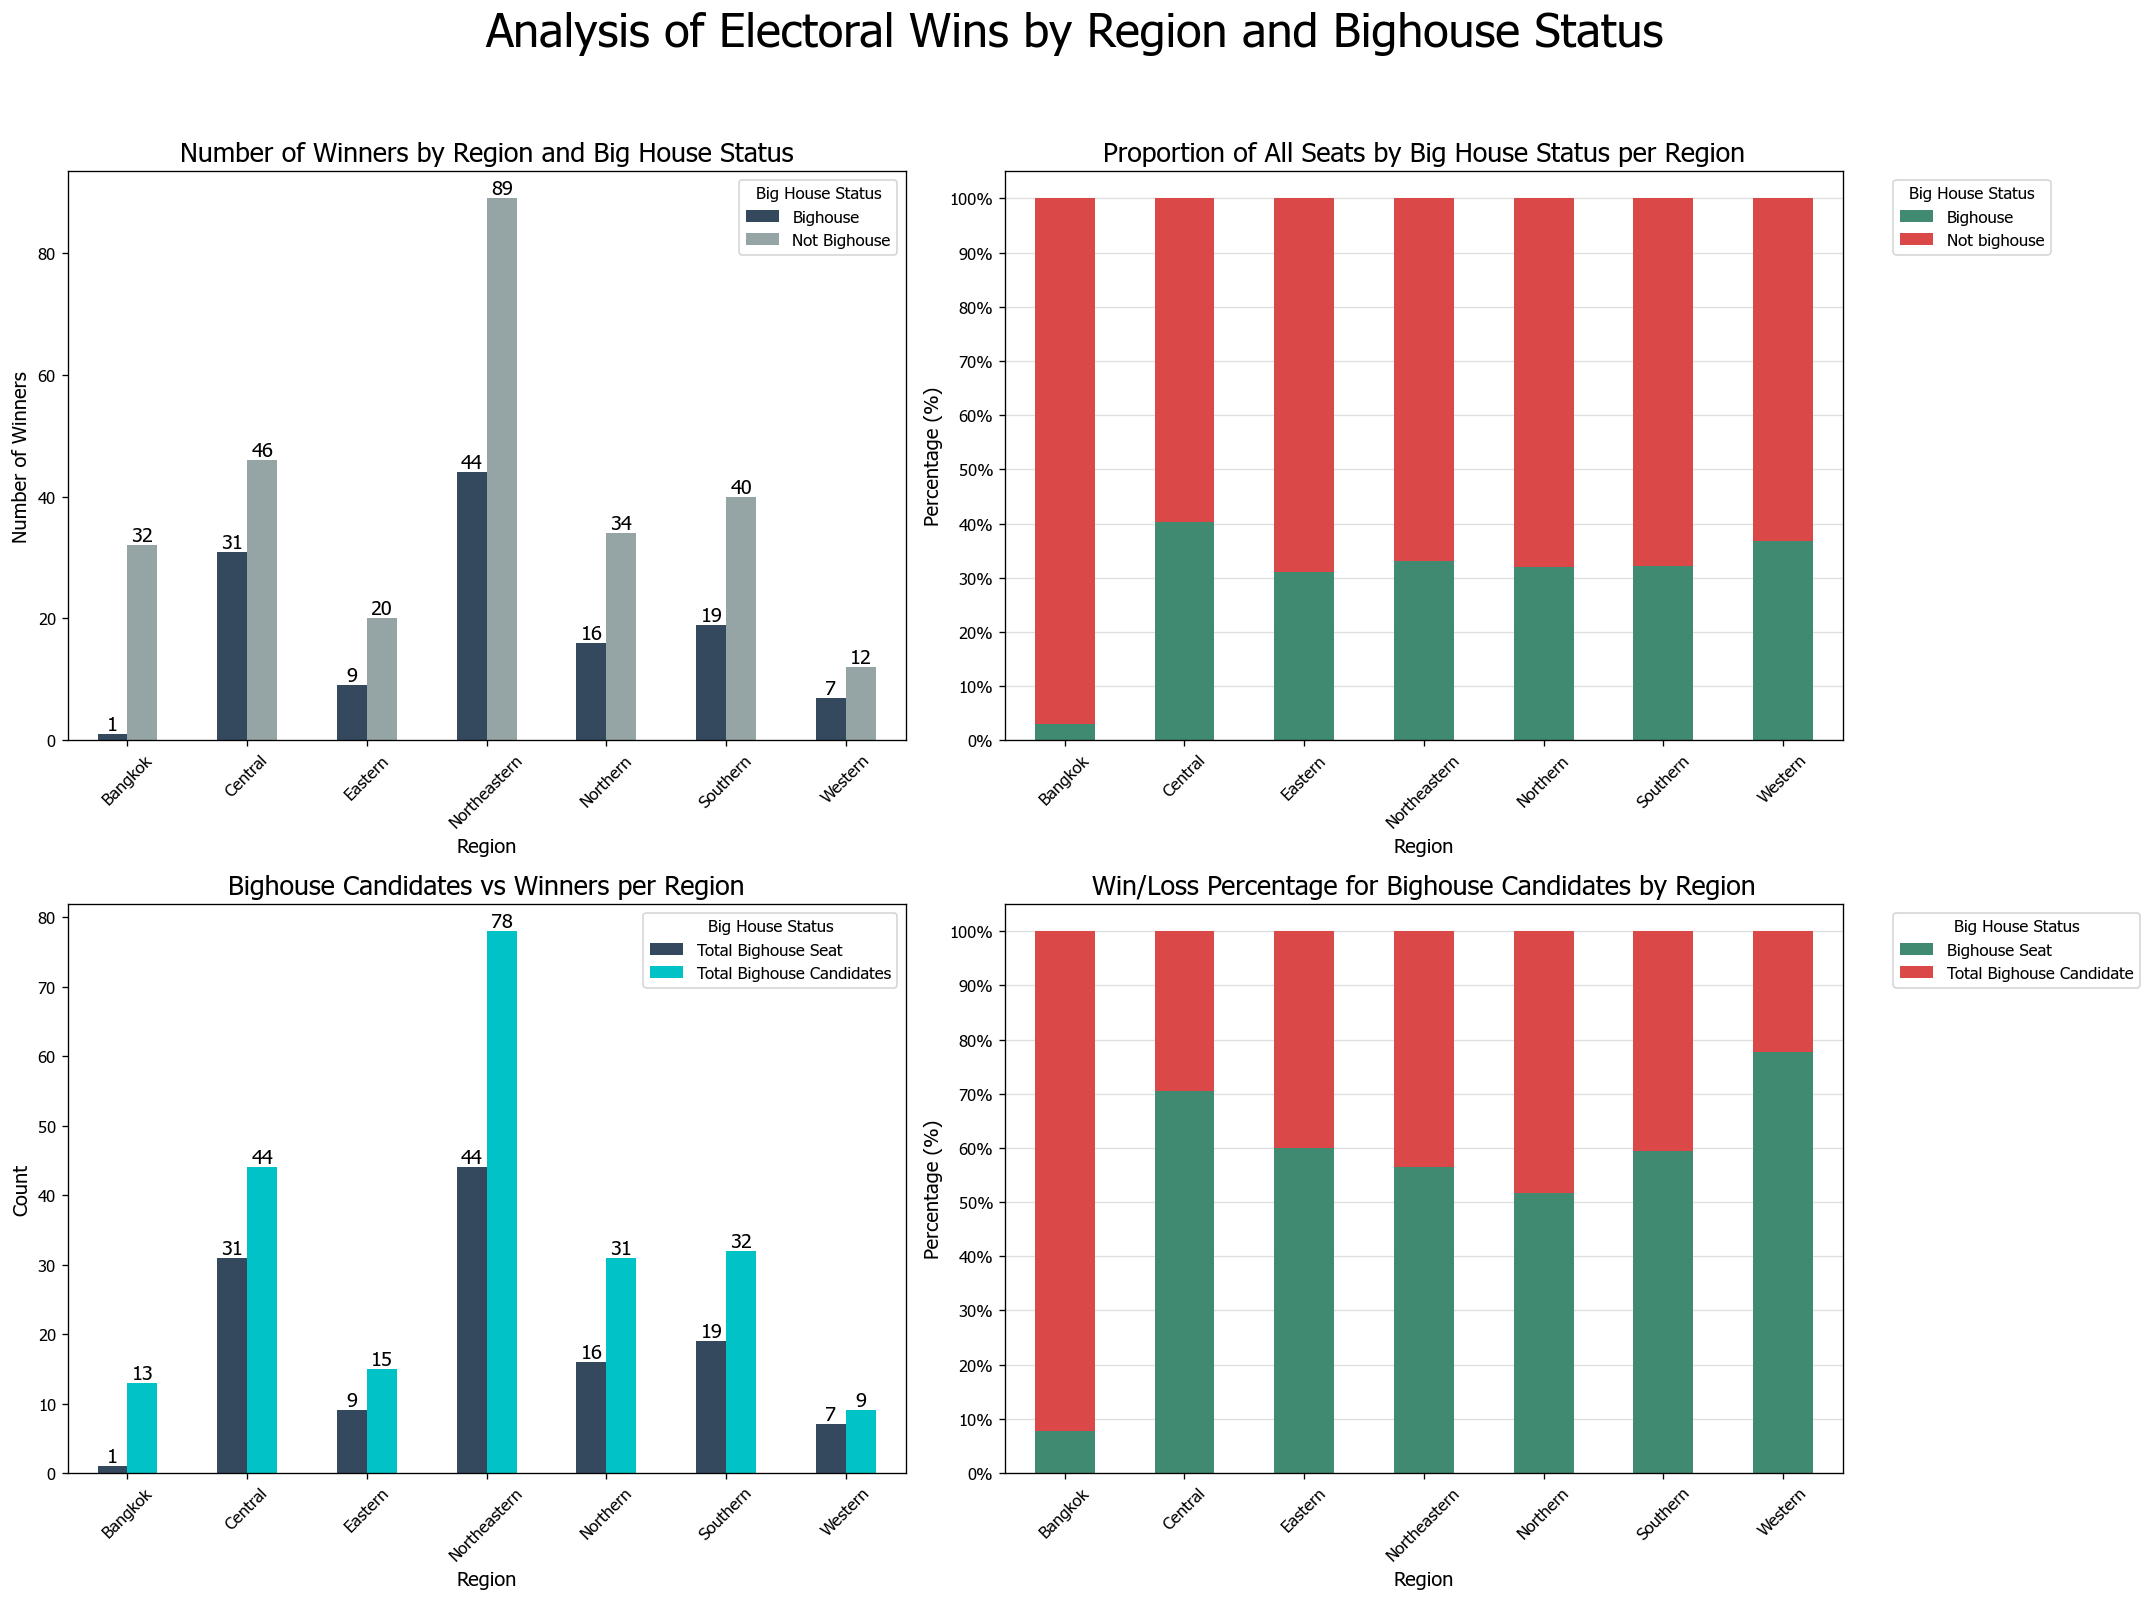

In [153]:
import matplotlib.ticker as mticker
import numpy as np

winner_by_region_bighouse = df_cal_score_per_candidate_bighouse.groupby(['region', 'bighouse'])['is_winner'].sum().unstack(fill_value=0)

bighouse_candidates_by_region = df_cal_score_per_candidate_bighouse[
    df_cal_score_per_candidate_bighouse['bighouse'] == 'bighouse'
].groupby(['region', 'is_winner']).size().unstack(fill_value=0)

bighouse_percentages_by_region = bighouse_candidates_by_region.apply(lambda x: x / x.sum() * 100, axis=1)

bighouse_percentages_by_region_reordered = bighouse_percentages_by_region[[1, 0]]

total_bighouse_winners_per_region = bighouse_candidates_by_region[1]
total_bighouse_losers_per_region = bighouse_candidates_by_region[0]
total_bighouse_candidates_per_region = bighouse_candidates_by_region.sum(axis=1)

bighouse_summary_table = pd.DataFrame({
    'Total Bighouse Seat': total_bighouse_winners_per_region,
    'Total Bighouse Losers': total_bighouse_losers_per_region,
    'Total Bighouse Candidates': total_bighouse_candidates_per_region
})

bighouse_summary_table = bighouse_summary_table.reset_index().rename(columns={'region': 'Region'})

total_winners_per_region = winner_by_region_bighouse.sum(axis=1)
proportion_of_all_winners_by_bighouse_status = (
    winner_by_region_bighouse.div(total_winners_per_region.replace(0, np.nan), axis=0) * 100
).fillna(0)

check_winner_graph = pd.pivot_table(
    df_cal_score_per_candidate_bighouse,
    values = 'is_winner',
    index = 'bighouse',
    aggfunc = {
        'is_winner' : 'sum'}
)


fig, axes = plt.subplots(2,2, figsize=(18, 14))
fig.suptitle('Analysis of Electoral Wins by Region and Bighouse Status', fontsize=28)

# Plot 1
winner_by_region_bighouse.plot(kind='bar', stacked=False, ax=axes[0,0], color=['#34495e', '#95a5a6'])
axes[0,0].set_title('Number of Winners by Region and Big House Status', fontsize=16)
axes[0,0].set_xlabel('Region', fontsize=12)
axes[0,0].set_ylabel('Number of Winners', fontsize=12)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend(title='Big House Status', labels=['Bighouse', 'Not Bighouse'])
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%d', fontsize=12)

# Plot 2
proportion_of_all_winners_by_bighouse_status.plot(kind='bar', stacked=True, ax=axes[0,1], color=['#408A71', '#DA4848'])
axes[0,1].set_title('Proportion of All Seats by Big House Status per Region', fontsize=16)
axes[0,1].set_xlabel('Region', fontsize=12)
axes[0,1].set_ylabel('Percentage (%)', fontsize=12)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Big House Status', labels=['Bighouse', 'Not bighouse'], bbox_to_anchor=(1.05, 1))
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0,1].set_yticks(np.arange(0, 101, 10))
axes[0,1].yaxis.grid(True, linestyle='-', alpha=0.4)
axes[0,1].set_axisbelow(True)

# Plot 3
bighouse_summary_table_for_plot = bighouse_summary_table[['Region', 'Total Bighouse Seat' , 'Total Bighouse Candidates']].set_index('Region')
bighouse_summary_table_for_plot.plot(kind='bar', stacked=False, ax=axes[1, 0], color=['#34495e', '#00C2C7'])
axes[1, 0].set_title('Bighouse Candidates vs Winners per Region', fontsize=16)
axes[1, 0].set_xlabel('Region', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Big House Status')
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%d', fontsize=12)

# Plot 4
bighouse_percentages_by_region_reordered.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#408A71', '#DA4848'])
axes[1, 1].set_title('Win/Loss Percentage for Bighouse Candidates by Region', fontsize=16)
axes[1, 1].set_xlabel('Region', fontsize=12)
axes[1, 1].set_ylabel('Percentage (%)', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Big House Status', labels=['Bighouse Seat', 'Total Bighouse Candidate'], bbox_to_anchor=(1.05, 1))
axes[1, 1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1, 1].set_yticks(np.arange(0, 101, 10))
axes[1, 1].yaxis.grid(True, linestyle='-', alpha=0.4)
axes[1, 1].set_axisbelow(True)

display(bighouse_summary_table)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Section 3: Behavioral Report


# Final Behavioral Analysis Report
*Comprehensive Narrative: Voter Mobilization to Micro-Level Behavior*

### Executive Summary
This report analyzes the behavioral patterns of the 2023 Thai General Election, focusing on voter engagement, competitiveness, and regional dynamics. We focus on constituencies with at least 80% reported counts to ensure high-fidelity insights.

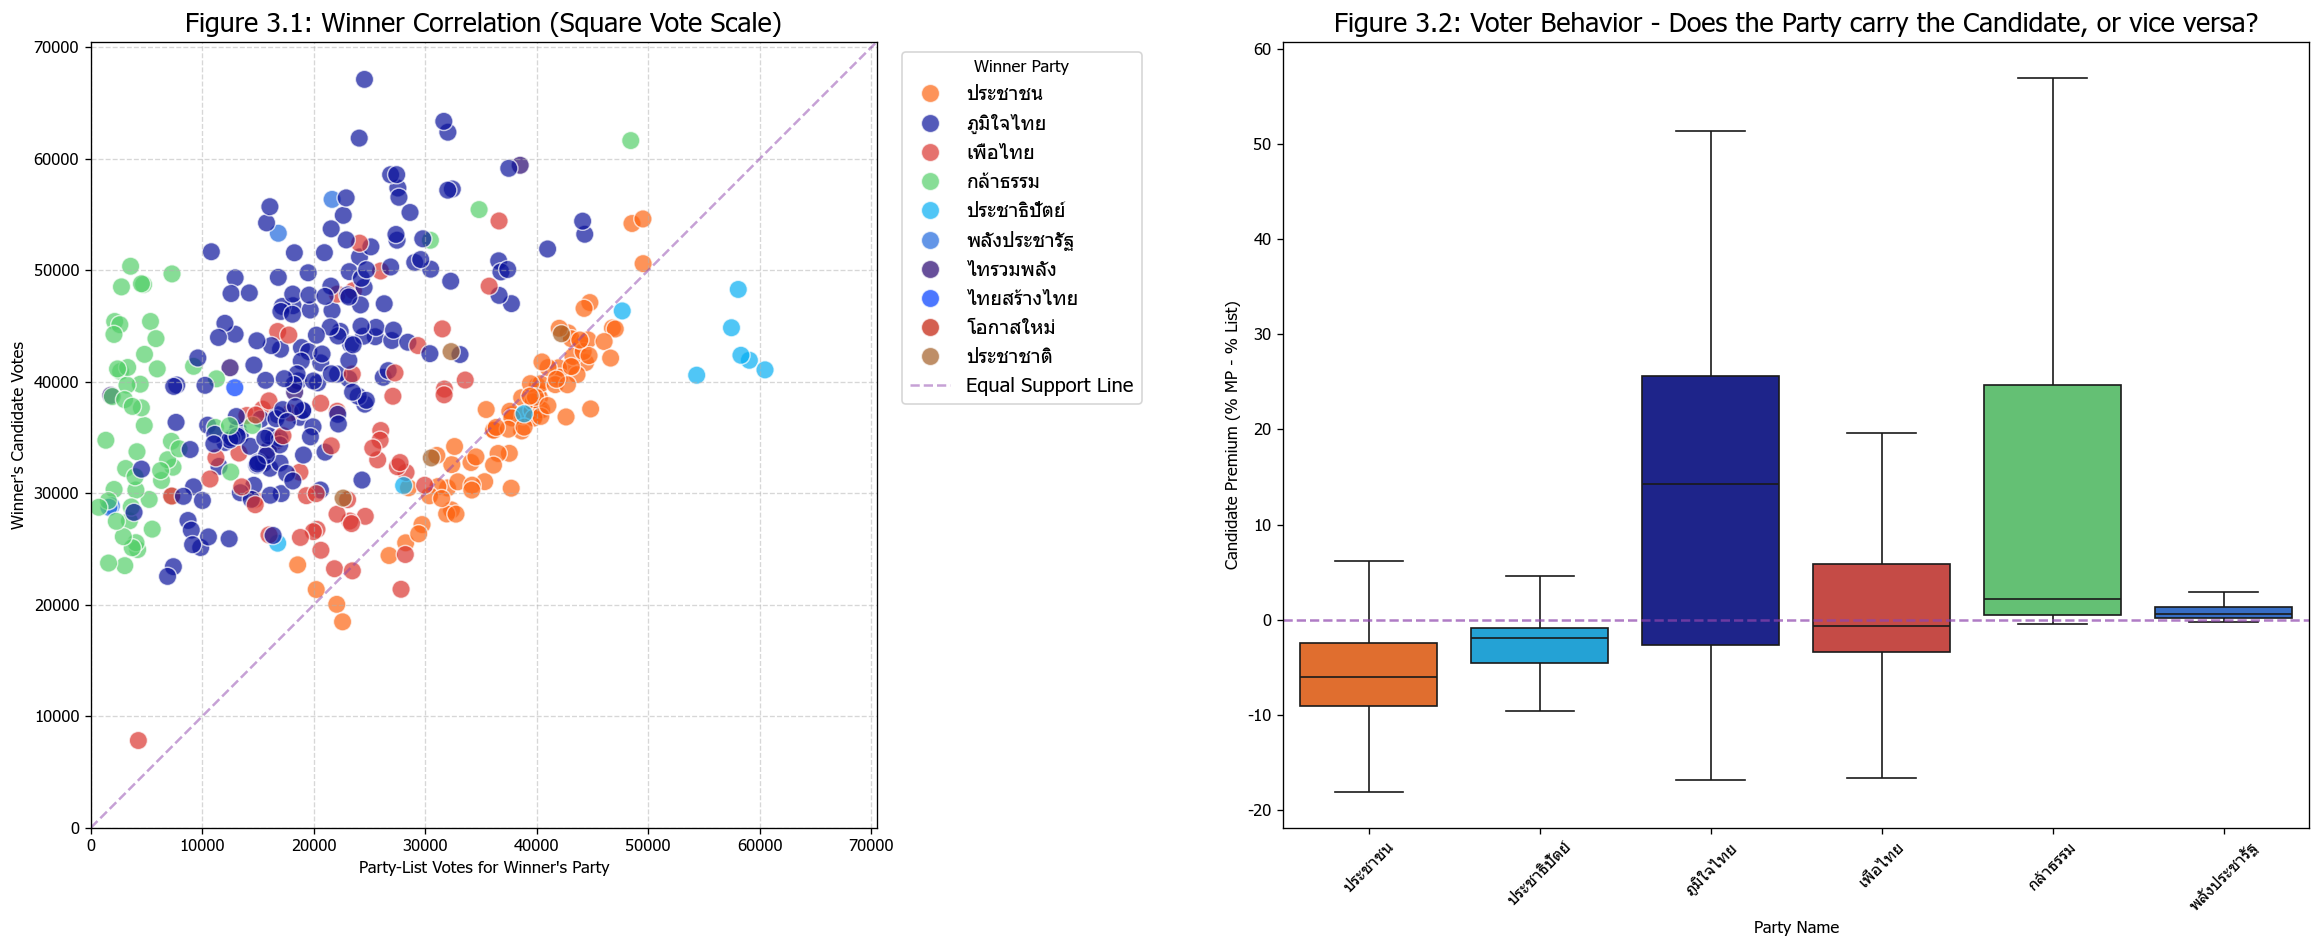

In [154]:

all_candidates_df = split_ticket_df.copy()
# Merge with df_stats_cons_summary for votes and df_constituencies for prov_id
all_candidates_df = all_candidates_df.merge(df_stats_cons_summary[['cons_id', 'party_list_valid_votes']], on='cons_id', how='left')
all_candidates_df = all_candidates_df.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id', how='left')

all_candidates_df['party_list_vote_percent'] = (all_candidates_df['party_list_vote'] / all_candidates_df['party_list_valid_votes'] * 100).fillna(0)
all_candidates_df['gap'] = all_candidates_df['mp_app_vote_percent'] - all_candidates_df['party_list_vote_percent']
top_parties = all_candidates_df.groupby('party_name')['mp_app_vote'].sum().nlargest(6).index
plot_df = all_candidates_df[all_candidates_df['party_name'].isin(top_parties)]

max_votes_win = max(winner_split_df['party_list_vote'].max(), winner_split_df['mp_app_vote'].max()) * 1.05
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(data=winner_split_df, x='party_list_vote', y='mp_app_vote', hue='party_name', palette=party_colors, s=120, alpha=0.7, edgecolor='w', ax=axes[0])
axes[0].set_xlim(0, max_votes_win)
axes[0].set_ylim(0, max_votes_win)
axes[0].set_aspect('equal', adjustable='box')
axes[0].plot([0, max_votes_win], [0, max_votes_win], linestyle='--', color=REFERENCE_LINE, alpha=0.5, label='Equal Support Line')
axes[0].set_title('Figure 3.1: Winner Correlation (Square Vote Scale)', fontsize=16)
axes[0].set_xlabel('Party-List Votes for Winner\'s Party')
axes[0].set_ylabel('Winner\'s Candidate Votes')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Winner Party', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

sns.boxplot(data=plot_df, x='party_name', y='gap', palette=party_colors, showfliers=False, ax=axes[1])
axes[1].axhline(0, color=REFERENCE_LINE, linestyle='--', alpha=0.7)
axes[1].set_title('Figure 3.2: Voter Behavior - Does the Party carry the Candidate, or vice versa?', fontsize=16)
axes[1].set_ylabel('Candidate Premium (% MP - % List)')
axes[1].set_xlabel('Party Name')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

In [155]:
all_candidates_df = split_ticket_df.copy()

# Fix: Merge with df_stats_cons_summary for votes and df_constituencies for prov_id
all_candidates_df = all_candidates_df.merge(df_stats_cons_summary[['cons_id', 'party_list_valid_votes']], on='cons_id', how='left')
all_candidates_df = all_candidates_df.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id', how='left')

all_candidates_df['party_list_vote_percent'] = (all_candidates_df['party_list_vote'] / all_candidates_df['party_list_valid_votes'] * 100).fillna(0)
all_candidates_df['gap'] = all_candidates_df['mp_app_vote_percent'] - all_candidates_df['party_list_vote_percent']

top_parties = all_candidates_df.groupby('party_name')['mp_app_vote'].sum().nlargest(6).index
plot_df = all_candidates_df[all_candidates_df['party_name'].isin(top_parties)]

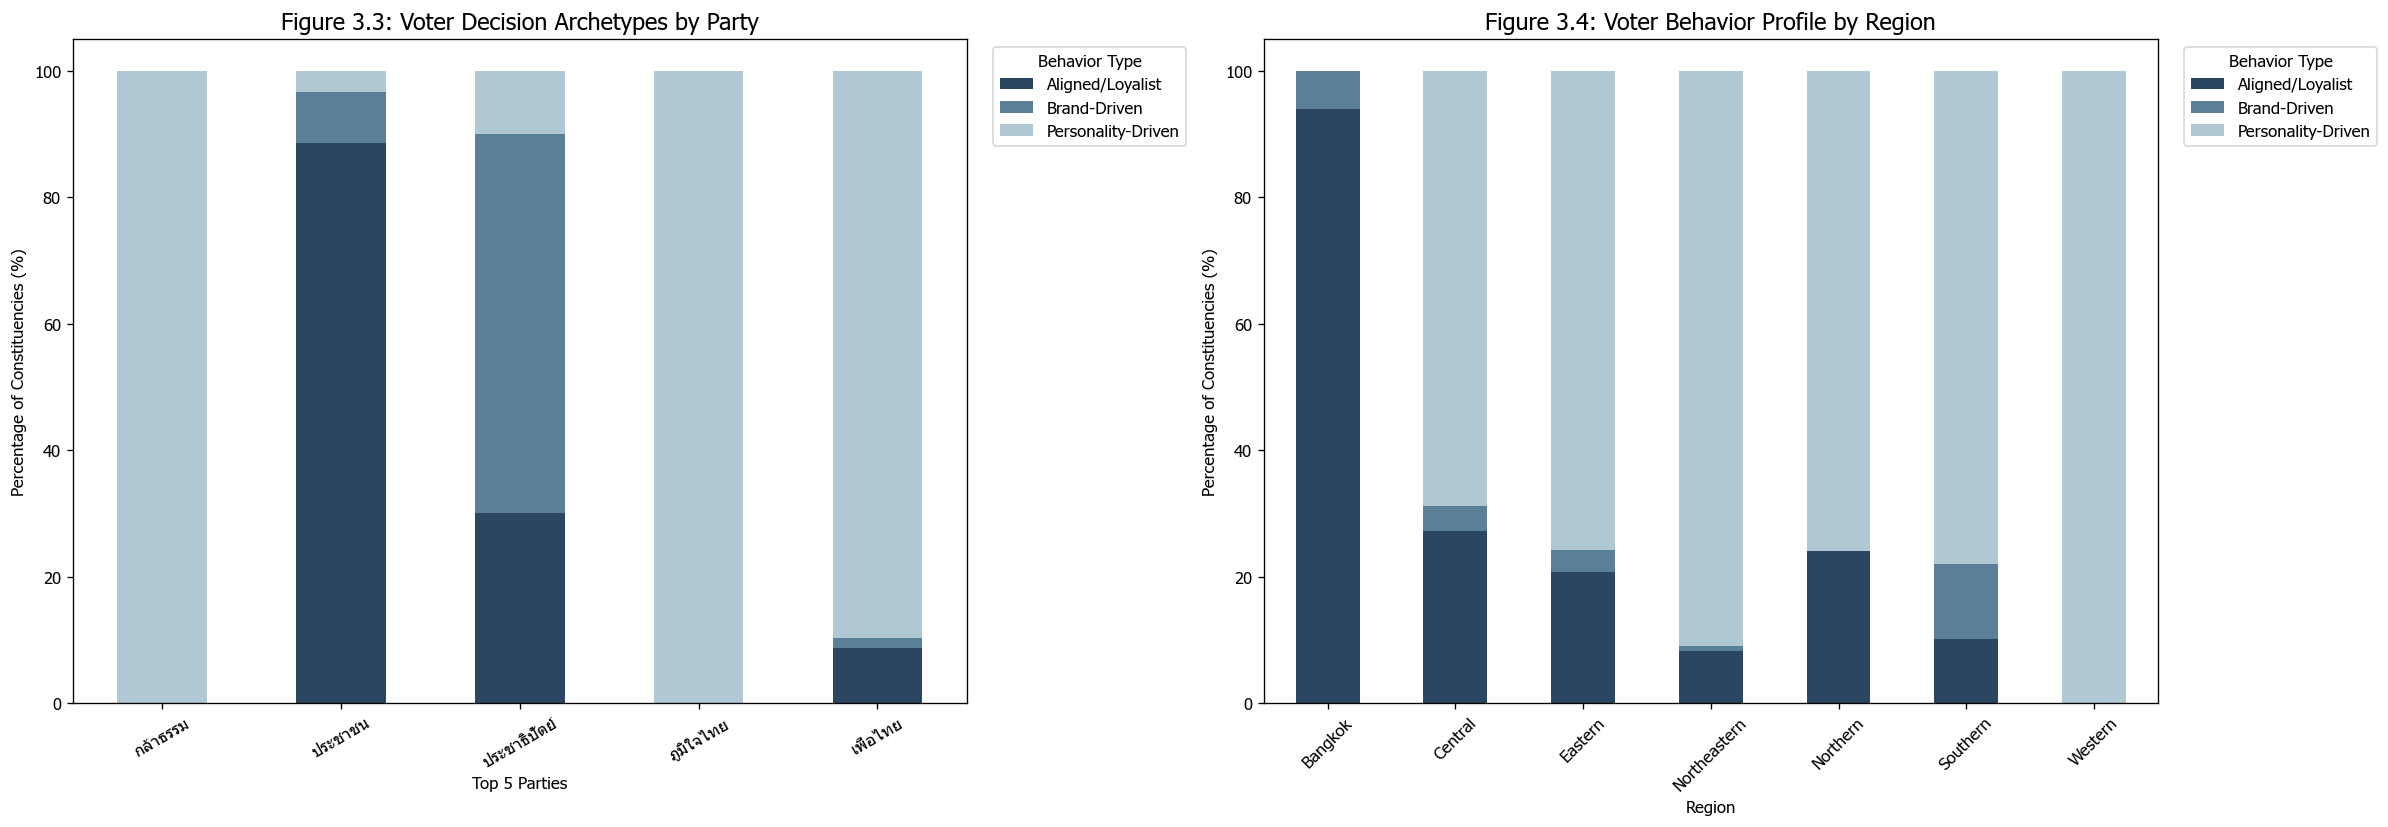

In [156]:
# Build behavior inputs for Figures 3.3 and 3.4.
# Fix: Split merge to get prov_id from df_constituencies
winner_split_df = winner_split_df.merge(df_stats_cons_summary[['cons_id', 'party_list_valid_votes']], on='cons_id', how='left')
winner_split_df = winner_split_df.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id', how='left')

winner_split_df['party_list_vote_percent'] = (winner_split_df['party_list_vote'] / winner_split_df['party_list_valid_votes'] * 100).fillna(0)
winner_split_df['tactical_gap'] = winner_split_df['mp_app_vote_percent'] - winner_split_df['party_list_vote_percent']
winner_split_df = winner_split_df.merge(df_prov_full[['prov_id', 'region']], on='prov_id', how='left')

def categorize_behavior(gap):
    if gap > 5: return 'Personality-Driven'
    elif gap < -5: return 'Brand-Driven'
    else: return 'Aligned/Loyalist'

winner_split_df['behavior_type'] = winner_split_df['tactical_gap'].apply(categorize_behavior)

behavior_df = winner_split_df.dropna(subset=['region']).copy()
top_5_parties = behavior_df['party_name'].value_counts().head(5).index
party_behavior_df = behavior_df[behavior_df['party_name'].isin(top_5_parties)].copy()
party_breakdown = party_behavior_df.groupby(['party_name', 'behavior_type']).size().unstack(fill_value=0)
party_breakdown_pct = party_breakdown.div(party_breakdown.sum(axis=1), axis=0) * 100
regional_breakdown = behavior_df.groupby(['region', 'behavior_type']).size().unstack(fill_value=0)
regional_breakdown_pct = regional_breakdown.div(regional_breakdown.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

party_breakdown_pct.plot(kind='bar', stacked=True, color=BEHAVIOR_COLORS, ax=axes[0])
axes[0].set_title('Figure 3.3: Voter Decision Archetypes by Party', fontsize=14)
axes[0].set_xlabel('Top 5 Parties')
axes[0].set_ylabel('Percentage of Constituencies (%)')
axes[0].legend(title='Behavior Type', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=30)

regional_breakdown_pct.plot(kind='bar', stacked=True, color=BEHAVIOR_COLORS, ax=axes[1])
axes[1].set_title('Figure 3.4: Voter Behavior Profile by Region', fontsize=14)
axes[1].set_ylabel('Percentage of Constituencies (%)')
axes[1].set_xlabel('Region')
axes[1].legend(title='Behavior Type', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

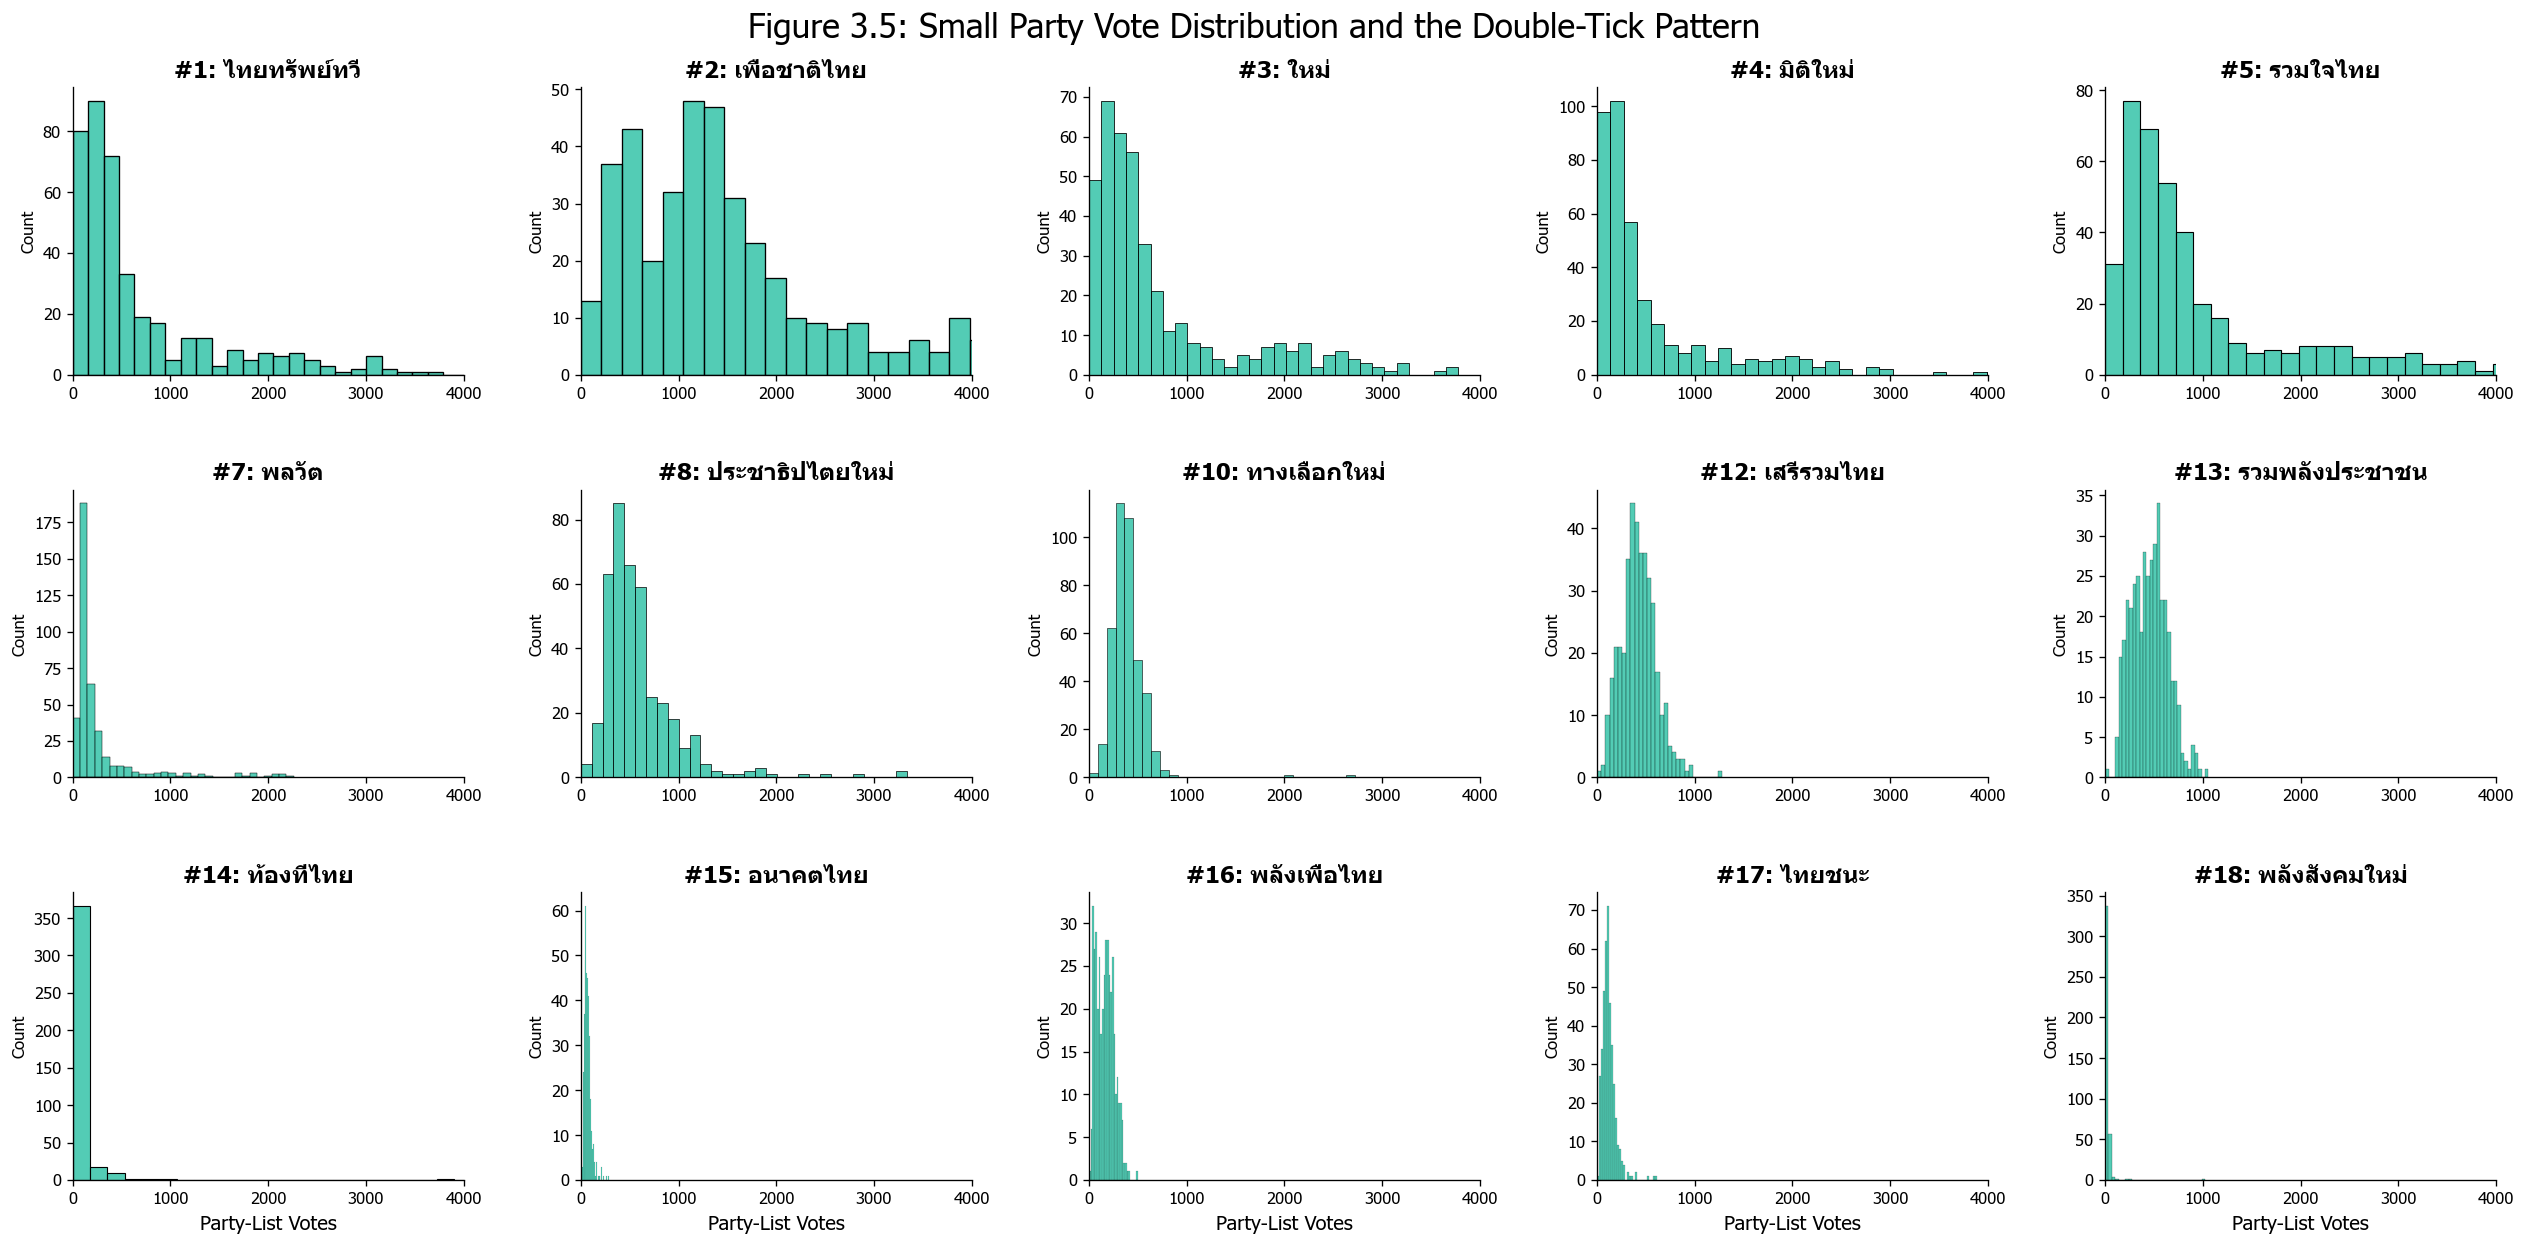

In [157]:

top_6_ids = df_stats_cons_party.groupby('party_id')['party_list_vote'].sum().nlargest(6).index.tolist()

df_party_info['party_no_num'] = pd.to_numeric(df_party_info['party_no'], errors='coerce')
target_parties = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 19))) &
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_1_20 = df_stats_cons_party.merge(target_parties, left_on='party_id', right_on='id')

# Keep common x-scale across facets.
g = sns.FacetGrid(votes_1_20, col="name", col_wrap=5, sharex=True, sharey=False, height=3.5, aspect=1.2)
g.map(sns.histplot, "party_list_vote", bins=30, color=NONPARTY_SINGLE, alpha=0.75)

for ax in g.axes.flat:
    title_text = ax.get_title().split('= ')[-1]
    p_no = target_parties[target_parties['name'] == title_text]['party_no_num'].values[0]

    ax.set_title(f"#{int(p_no)}: {title_text}", fontsize=14, fontweight='bold')

    ax.set_xlabel('Party-List Votes', fontsize=12, labelpad=5)
    ax.tick_params(labelbottom=True)

    ax.set_xlim(0, 4000)

plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
g.fig.suptitle('Figure 3.5: Small Party Vote Distribution and the Double-Tick Pattern', fontsize=20)

plt.show()

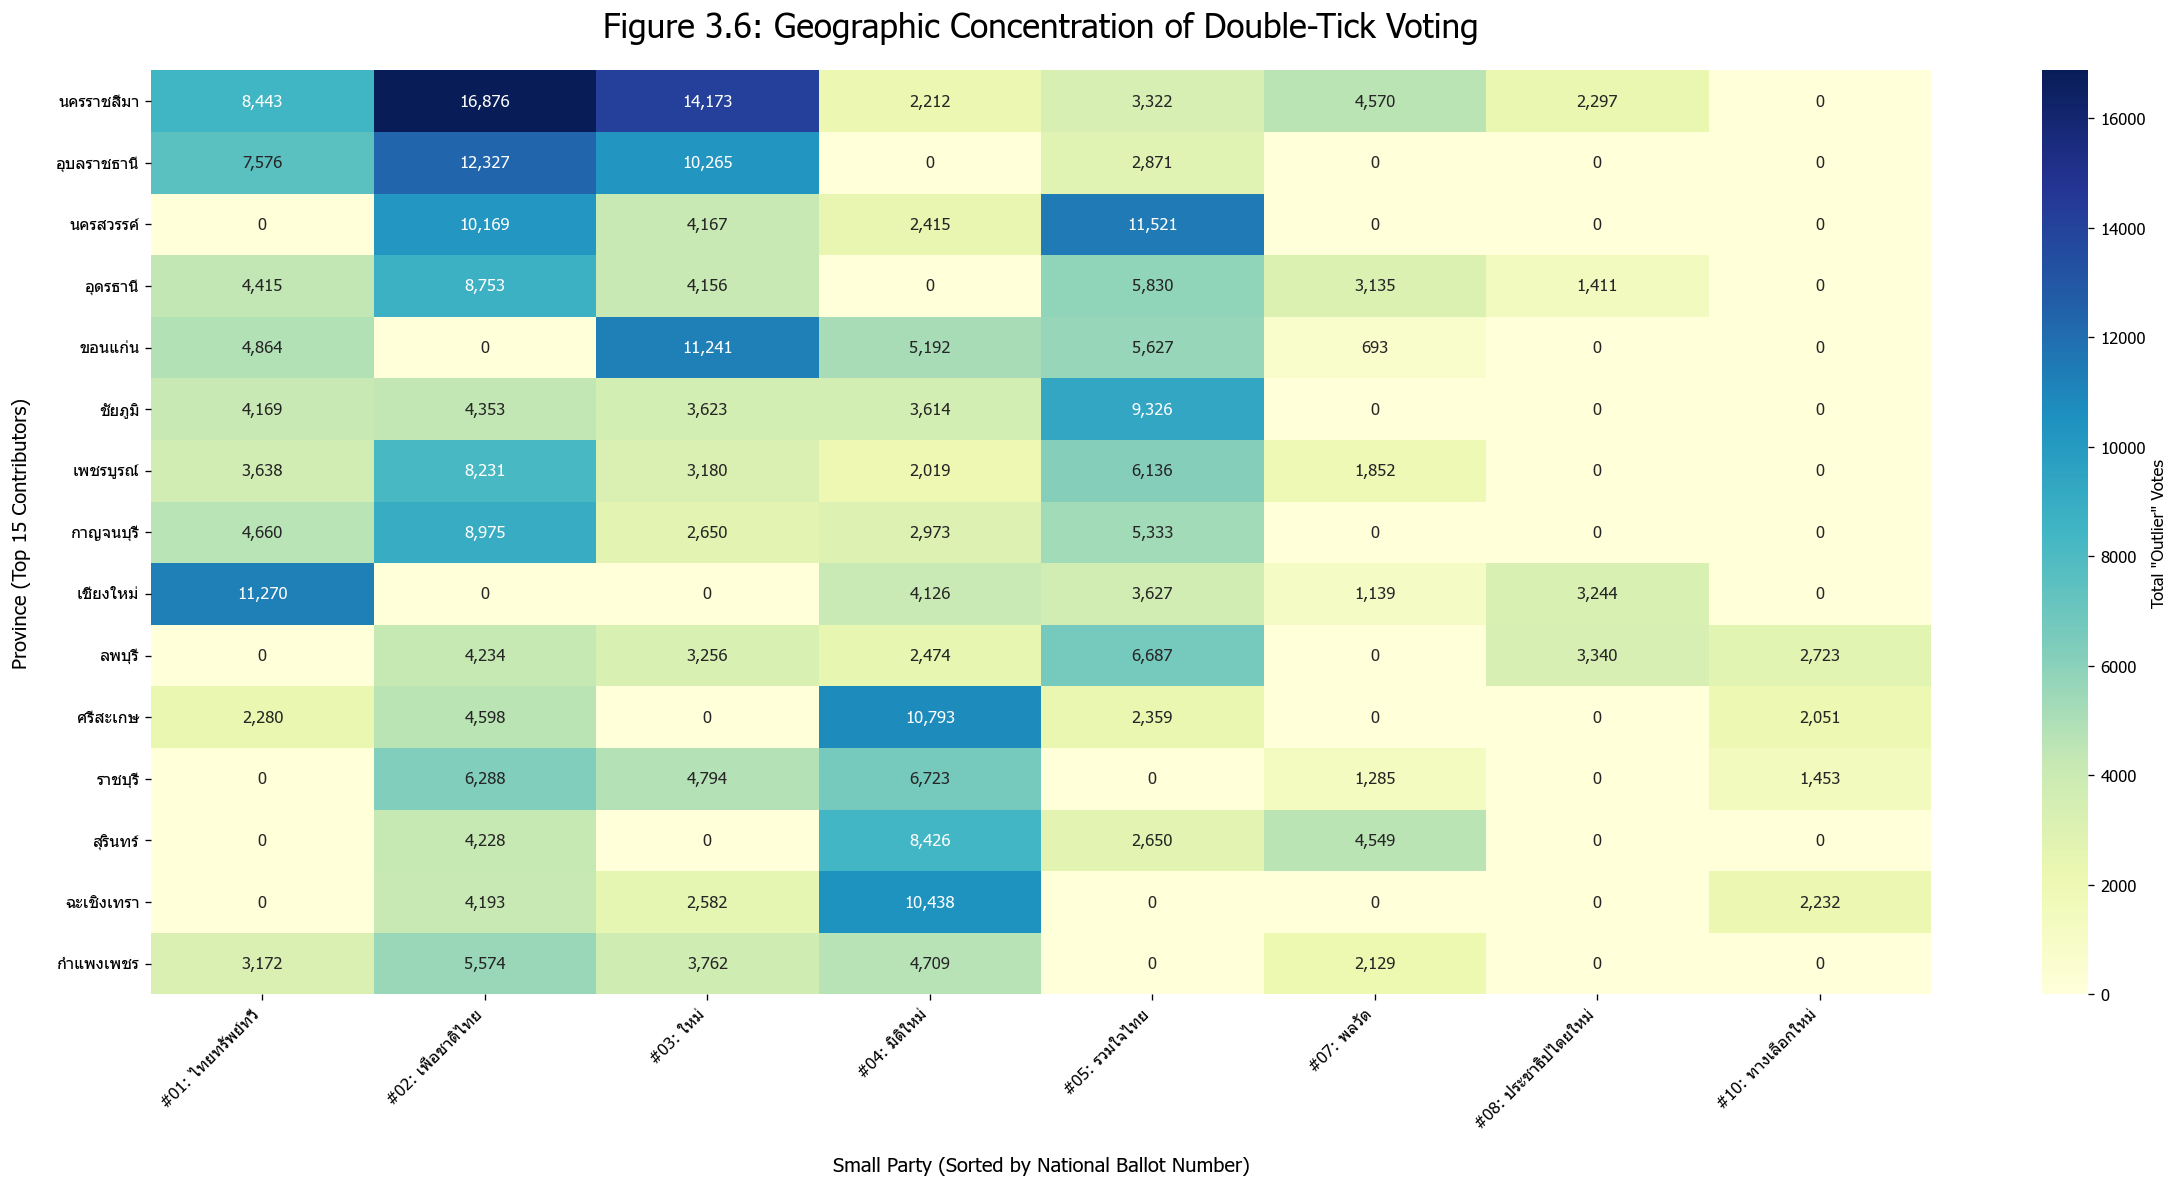

In [158]:
# Figure 3.6 prep.
top_6_ids = df_stats_cons_party.groupby('party_id')['party_list_vote'].sum().nlargest(6).index.tolist()
df_party_info['party_no_num'] = pd.to_numeric(df_party_info['party_no'], errors='coerce')

target_small_parties = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 11))) &
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_small = df_stats_cons_party.merge(target_small_parties, left_on='party_id', right_on='id')

q_stats = votes_small.groupby('name')['party_list_vote'].agg([
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'Q1', '<lambda_1>': 'Q3'})
q_stats['IQR'] = q_stats['Q3'] - q_stats['Q1']
q_stats['Upper_Fence'] = q_stats['Q3'] + (1.5 * q_stats['IQR'])

votes_small = votes_small.merge(q_stats[['Upper_Fence']], left_on='name', right_index=True)
spikes_only = votes_small[votes_small['party_list_vote'] > votes_small['Upper_Fence']].copy()

spikes_with_prov = spikes_only.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id')

# Use Thai province names on y-axis
prov_name_col = 'province' if 'province' in df_prov_full.columns else next((c for c in ['province_name_en', 'prov_name_en', 'name_en'] if c in df_prov_full.columns), df_prov_full.columns[1])
final_spikes = spikes_with_prov.merge(df_prov_full[['prov_id', prov_name_col]], on='prov_id')

final_spikes['party_label'] = (
    "#" + final_spikes['party_no_num'].astype(int).map('{:02d}'.format) +
    ": " + final_spikes['name']
)

prov_matrix = final_spikes.groupby([prov_name_col, 'party_label'])['party_list_vote'].sum().unstack(fill_value=0)

prov_matrix = prov_matrix.reindex(sorted(prov_matrix.columns), axis=1)
top_15_provs = prov_matrix.sum(axis=1).nlargest(15).index
final_heatmap_data = prov_matrix.loc[top_15_provs]

plt.figure(figsize=(20, 10))
sns.heatmap(final_heatmap_data, annot=True, fmt=',.0f', cmap=HEATMAP_CMAP, cbar_kws={'label': 'Total "Outlier" Votes'})

plt.title('Figure 3.6: Geographic Concentration of Double-Tick Voting', fontsize=20, pad=20)
plt.xlabel('Small Party (Sorted by National Ballot Number)', fontsize=12, labelpad=15)
plt.ylabel('Province (Top 15 Contributors)', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

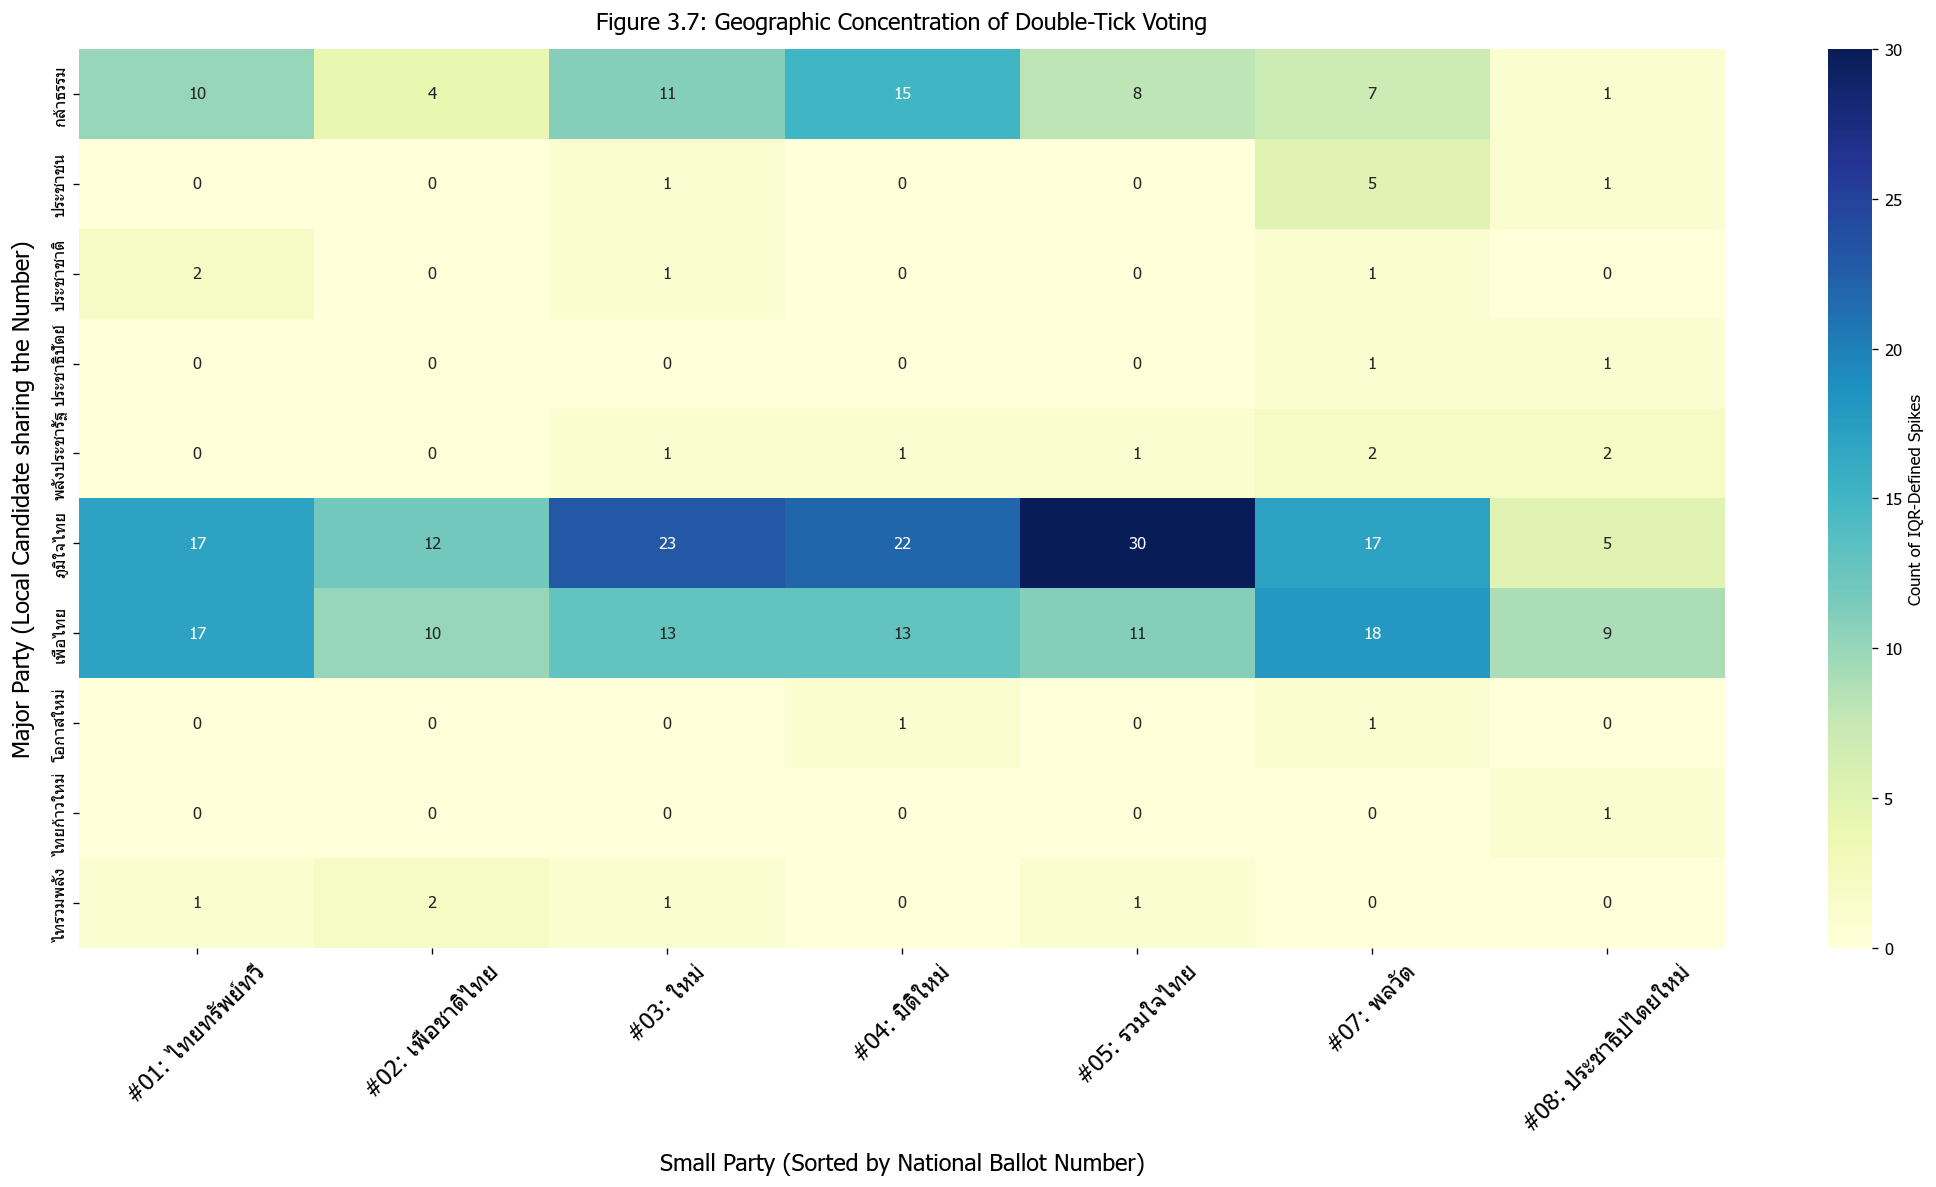

In [159]:
# Shared prep
top_6_ids = df_stats_cons_party.groupby('party_id')['party_list_vote'].sum().nlargest(6).index.tolist()

df_party_info['party_no_num'] = pd.to_numeric(df_party_info['party_no'], errors='coerce')
small_parties_df = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 21))) &
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_1_20 = df_stats_cons_party.merge(small_parties_df, left_on='party_id', right_on='id')

q_stats = votes_1_20.groupby('name')['party_list_vote'].agg([
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'Q1', '<lambda_1>': 'Q3'})

q_stats['IQR'] = q_stats['Q3'] - q_stats['Q1']
q_stats['Upper_Fence'] = q_stats['Q3'] + (1.5 * q_stats['IQR'])

votes_1_20 = votes_1_20.merge(q_stats[['Upper_Fence']], left_on='name', right_index=True)
iqr_spikes_df = votes_1_20[votes_1_20['party_list_vote'] > votes_1_20['Upper_Fence']].copy()

df_cand_temp = df_stats_cons_cand.copy()
df_cand_temp['local_no'] = df_cand_temp['mp_app_id'].str.split('_').str[-1].astype(int)

benefactor_map = iqr_spikes_df.merge(
    df_cand_temp,
    left_on=['cons_id', 'party_no_num'],
    right_on=['cons_id', 'local_no']
)

benefactor_map = benefactor_map.merge(
    df_party_info[['id', 'name']],
    left_on='party_id_y', right_on='id',
    suffixes=('_small', '_big')
)

benefactor_map['small_party_label'] = (
    "#" + benefactor_map['party_no_num'].astype(int).map('{:02d}'.format) +
    ": " + benefactor_map['name_small']
)

summary_iqr = benefactor_map.groupby(['name_big', 'small_party_label']).size().unstack(fill_value=0)
summary_iqr = summary_iqr.reindex(sorted(summary_iqr.columns), axis=1)

exclude_prefixes = ['#10:', '#14:', '#15:']
summary_iqr = summary_iqr[[c for c in summary_iqr.columns if not any(c.startswith(p) for p in exclude_prefixes)]]

# Plot Figure 3.7
fig37, ax37 = plt.subplots(figsize=(18, 10))

sns.heatmap(summary_iqr, annot=True, fmt='d', cmap=HEATMAP_CMAP, cbar_kws={'label': 'Count of IQR-Defined Spikes'}, ax=ax37)
ax37.set_title('Figure 3.7: Geographic Concentration of Double-Tick Voting', fontsize=14, pad=12)
ax37.set_xlabel('Small Party (Sorted by National Ballot Number)', fontsize=14, labelpad=10)
ax37.set_ylabel('Major Party (Local Candidate sharing the Number)', fontsize=14, labelpad=10)
ax37.tick_params(axis='x', rotation=45, labelsize=14)

plt.tight_layout()

plt.show()

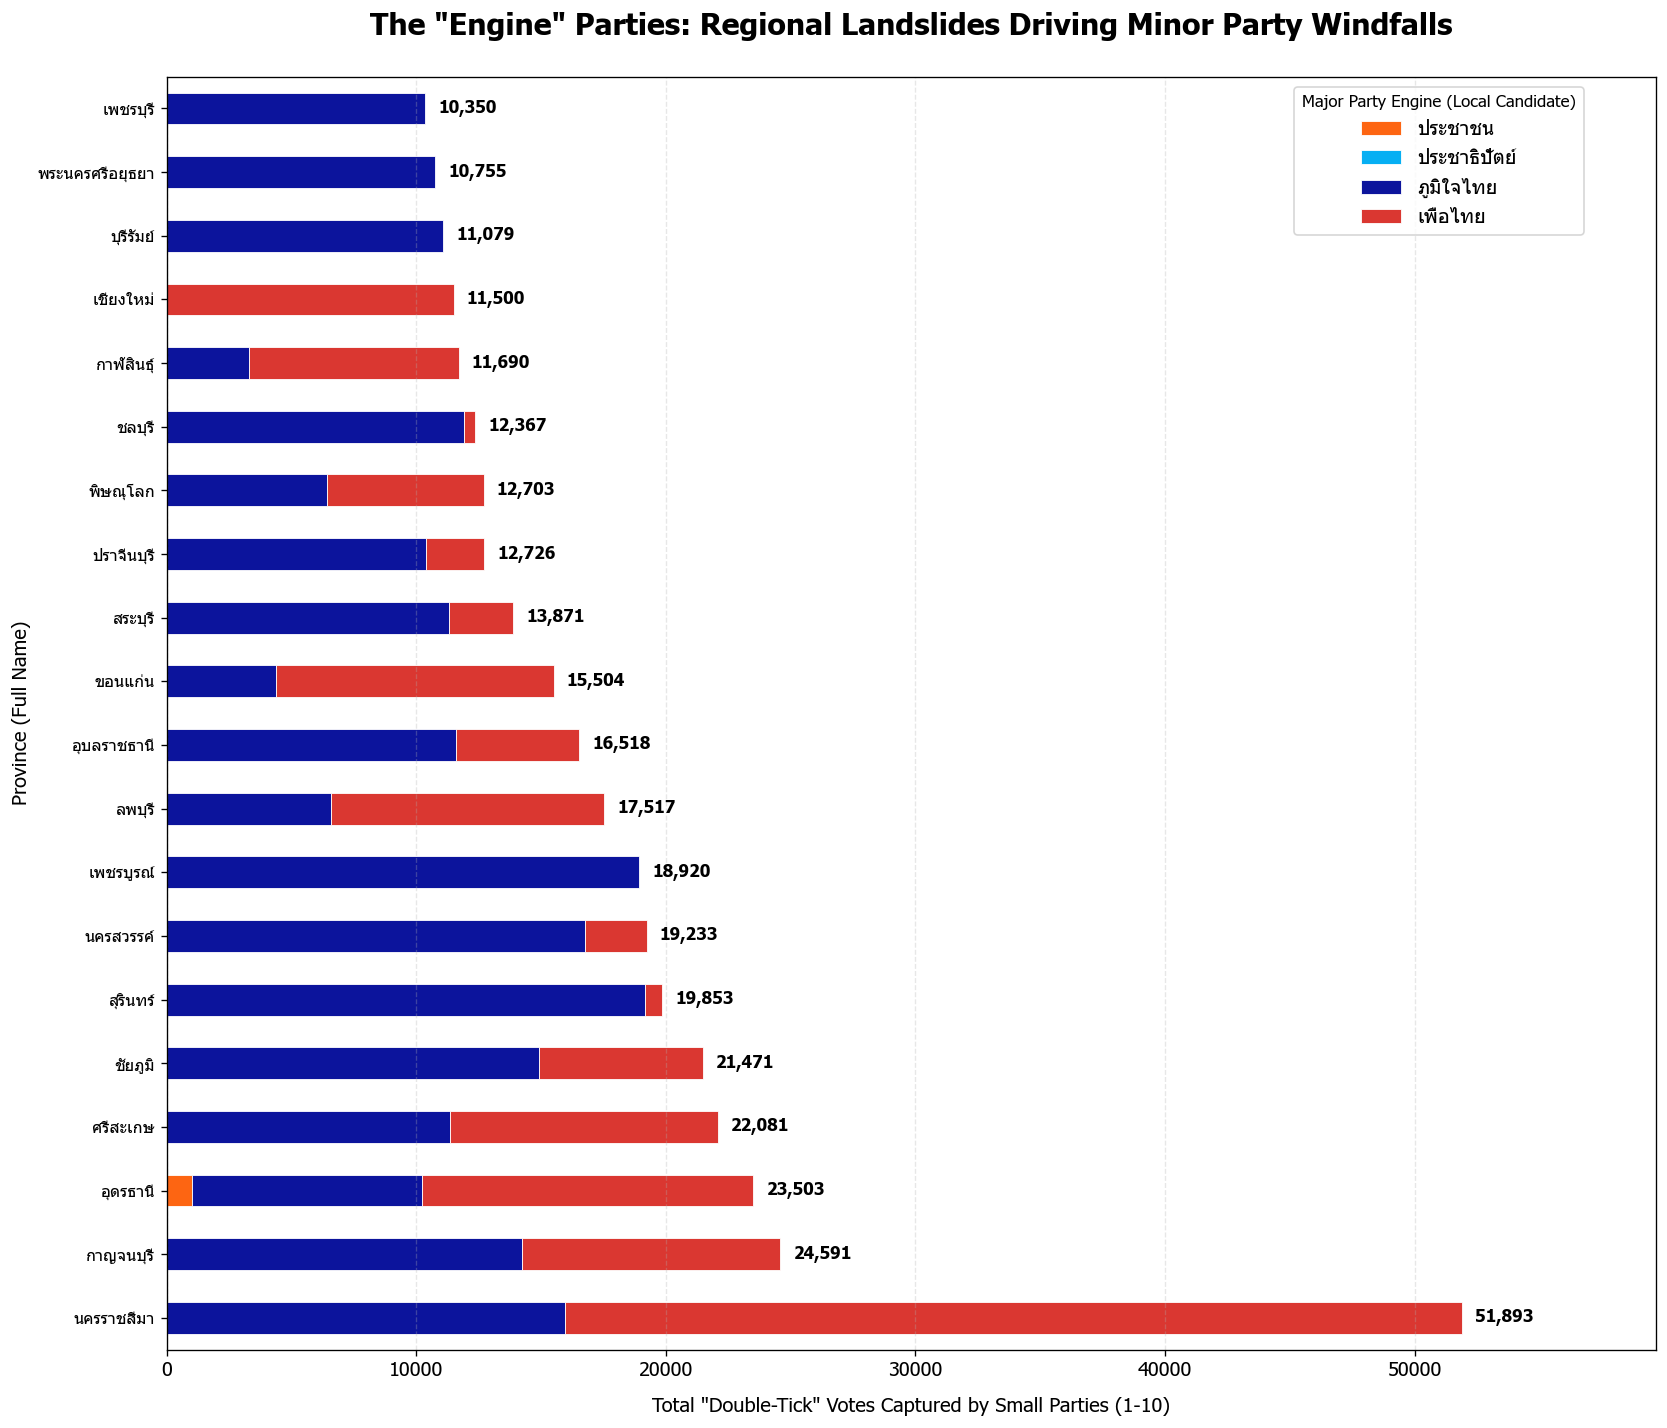

In [160]:
# Plot Figure 3.8
small_parties_1_10 = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 11))) &
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_small = df_stats_cons_party.merge(small_parties_1_10, left_on='party_id', right_on='id')
q_stats_small = votes_small.groupby('name')['party_list_vote'].agg([
    lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'Q1', '<lambda_1>': 'Q3'})
q_stats_small['Upper_Fence'] = q_stats_small['Q3'] + (1.5 * (q_stats_small['Q3'] - q_stats_small['Q1']))
votes_small = votes_small.merge(q_stats_small[['Upper_Fence']], left_on='name', right_index=True)
spikes = votes_small[votes_small['party_list_vote'] > votes_small['Upper_Fence']].copy()

spikes_with_prov = spikes.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id')
df_cand_big = df_stats_cons_cand[df_stats_cons_cand['party_id'].isin(top_6_ids)].copy()
df_cand_big['number'] = df_cand_big['mp_app_id'].str.split('_').str[-1].astype(int)
benefactor_data = spikes_with_prov.merge(
    df_cand_big[['cons_id', 'number', 'party_id']],
    left_on=['cons_id', 'party_no_num'],
    right_on=['cons_id', 'number']
)
final_data = benefactor_data.merge(df_prov_full[['prov_id', 'province']], on='prov_id')
final_data = final_data.merge(df_party_info[['id', 'name']], left_on='party_id_y', right_on='id', suffixes=('_small', '_big'))

engine_summary = final_data.groupby(['province', 'name_big'])['party_list_vote'].sum().unstack(fill_value=0)

top_20_provinces = engine_summary.sum(axis=1).nlargest(20).index
plot_subset = engine_summary.loc[top_20_provinces]

current_engines = plot_subset.columns.tolist()
colors_to_use = [party_colors.get(name, '#D3D3D3') for name in current_engines]

ax = plot_subset.plot(kind='barh', stacked=True, figsize=(14, 12), color=colors_to_use, edgecolor='white', linewidth=0.5)

row_totals = plot_subset.sum(axis=1)
for i, (province, total) in enumerate(row_totals.items()):
    ax.text(total + row_totals.max() * 0.01, i, f'{total:,.0f}',
            va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlim(0, row_totals.max() * 1.15)

plt.title('The "Engine" Parties: Regional Landslides Driving Minor Party Windfalls', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Total "Double-Tick" Votes Captured by Small Parties (1-10)', fontsize=12, labelpad=10)
plt.ylabel('Province (Full Name)', fontsize=12)
ax.tick_params(axis='x', labelsize=12)
plt.legend(title='Major Party Engine (Local Candidate)', bbox_to_anchor=(0.75, 1), loc='upper left', frameon=True, fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()